> **Recommended: run this notebook in Google Colab, nothing to install.**
>
> [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/04-run-our-reference-scenarios.ipynb)
>
> Just click on the "Open in Colab" button and follow along. Click the ▶ button on each cell (or press Shift+Enter) to see the results and move on to the next one.
>
> The documentation website shows pre-run results you can check if you don't want to or can't use Colab.

# Session 4: Run our reference scenarios

[Session 3](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/03-run-a-global-case.ipynb) introduced the Center's reference
scenarios: their geography, how the decks differ, and the regulatory assumptions behind
them. This session runs three of them exactly as they are, on the full yearly grid rather
than the coarse one Session 3 uses:

- `basecase_no_regulation`, `basecase_mid_regulation`, `basecase_strong_regulation`


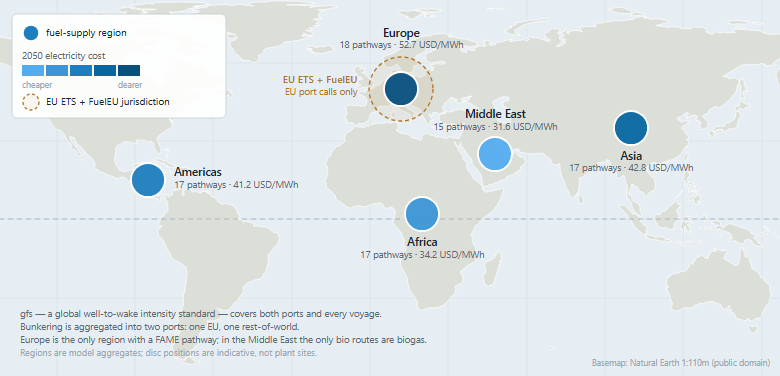

*The reference scenario's geography: five fuel-supply regions, the 2050 electricity
cost that feeds them, the production pathways each can host, and the EU jurisdiction
the ETS and FuelEU reach.*

## Setup

Running this on Colab or locally? The [workshop overview](https://github.com/zerocarbonshipping/navigate-zcs/blob/dev-workshop/docs/workshop/index.md) explains both; the cell below handles either case without changes.

In [1]:
# @title Setup
# Setup. Works both on Google Colab and in a local checkout of the repository;
# the workshop overview explains the two ways to run these notebooks.
import os
from pathlib import Path


# The branch these notebooks live on, and the one Colab clones. The "Open in
# Colab" badge at the top of the notebook, like the links between the
# notebooks, opens the copy on the workshop-colab branch instead: the same
# notebooks with their outputs cleared, rebuilt from this branch by
# .github/workflows/workshop-colab.yml. Change BRANCH, and that workflow, to
# "main" once the branch has been merged.
BRANCH = "dev-workshop"


def at_repo_root() -> bool:
    """True if the working directory is the root of the repository."""
    return Path("navigate").is_dir() and Path("assumptions").is_dir()


if at_repo_root():
    print("Already at the repository root.")
elif Path("../../navigate").is_dir():
    # Local Jupyter starts the kernel in the notebook's own folder,
    # docs/workshop/, but the paths below are relative to the repository root.
    os.chdir("../..")
    print("Moved up to the repository root.")
else:
    # Colab, or any other fresh environment
    if not Path("navigate-zcs").is_dir():
        !git clone --depth 1 -b {BRANCH} https://github.com/zerocarbonshipping/navigate-zcs.git
    os.chdir("navigate-zcs")
    print("Cloned the repository and moved into it.")

assert at_repo_root(), f"not at the repository root: {Path.cwd()}"

# `import navigate` is not a usable test here: from the repository root it
# succeeds because the source folder is present, which leaves the `navigate`
# command itself missing.
import sys
from importlib.metadata import PackageNotFoundError, version

try:
    print(f"Navigate {version('navigate-zcs')} is already installed.")
except PackageNotFoundError:
    %pip install -q .
    print("Installed Navigate.")

# The workshop's colours, shared with notebook 2 so the two cannot drift apart.
_STYLE_DIR = str(Path("docs/workshop").resolve())
if _STYLE_DIR not in sys.path:
    sys.path.insert(0, _STYLE_DIR)

from _style import (AXIS, GRID, INK, SUBINK, TICK, fuel_colour, fuel_label,
                    fuel_sorted, scen_colour)

Moved up to the repository root.
Navigate 1.0.0 is already installed.


## Run the scenarios

Run the next cell to solve the three scenarios in parallel.
Since this step takes a while, run it at the beginning of the workshop and come back to it later!

In [2]:
# @title Run the scenarios
import subprocess
import sys
import time
import os

# the three decks this session compares
deck_names = ["basecase_no_regulation", "basecase_mid_regulation", "basecase_strong_regulation"]

nav_files = {}
for name in deck_names:
    nav_file = f"simulations/scenarios/{name}/{name}.nav"
    assert os.path.exists(nav_file), f"Expected .nav file not found: {nav_file} -- check the scenario folder structure"
    nav_files[name] = nav_file

# the scenario the rest of this notebook inspects
scenario = "basecase_mid_regulation"

# This is the ~25 minute step: all three decks run at once.
processes = {}
console_logs = {}
started = time.time()

try:
    for name, nav_file in nav_files.items():
        console_path = f"simulations/scenarios/{name}/{name}_console.log"
        console_logs[name] = open(console_path, "w", encoding="utf-8")
        processes[name] = subprocess.Popen(
            [sys.executable, "-m", "navigate", nav_file, "-d", "./assumptions", "-e"],
            stdout=console_logs[name],
            stderr=subprocess.STDOUT,
        )
        print(f"started {name} (pid {processes[name].pid}) -> {console_path}")

    print("\nwaiting for all three to finish ...")
    for name, process in processes.items():
        code = process.wait()
        status = "ok" if code == 0 else f"FAILED (exit {code})"
        print(f"  {name:28} {status:20} {time.time() - started:6.0f} s elapsed")
finally:
    for handle in console_logs.values():
        handle.close()


started basecase_no_regulation (pid 34504) -> simulations/scenarios/basecase_no_regulation/basecase_no_regulation_console.log
started basecase_mid_regulation (pid 20316) -> simulations/scenarios/basecase_mid_regulation/basecase_mid_regulation_console.log
started basecase_strong_regulation (pid 10496) -> simulations/scenarios/basecase_strong_regulation/basecase_strong_regulation_console.log

waiting for all three to finish ...


  basecase_no_regulation       ok                      730 s elapsed


  basecase_mid_regulation      ok                     1431 s elapsed


  basecase_strong_regulation   ok                     1518 s elapsed


## Inspect the output plots

We read `basecase_mid_regulation`'s output here; the comparison at the end of
this session puts all three scenarios together.

The scenario decks load `DefaultPlot`, so the exact set of plots produced
depends on that default module — rather than assume its contents, we display
whatever image files land in the scenario's `plots/` folder. Every plot label
you might see is documented, grouped by category, in the reference manual's
[Plot Node Labels](https://zerocarbonshipping.github.io/navigate-zcs/reference_manual/plot.html)
appendix — e.g. `global_fuel_consumed` for the fuel mix, `global_emission_absolute`
for emissions, or `regulation_compliance` for how the "gfs" regulation binds.

### Engine fuel consumed

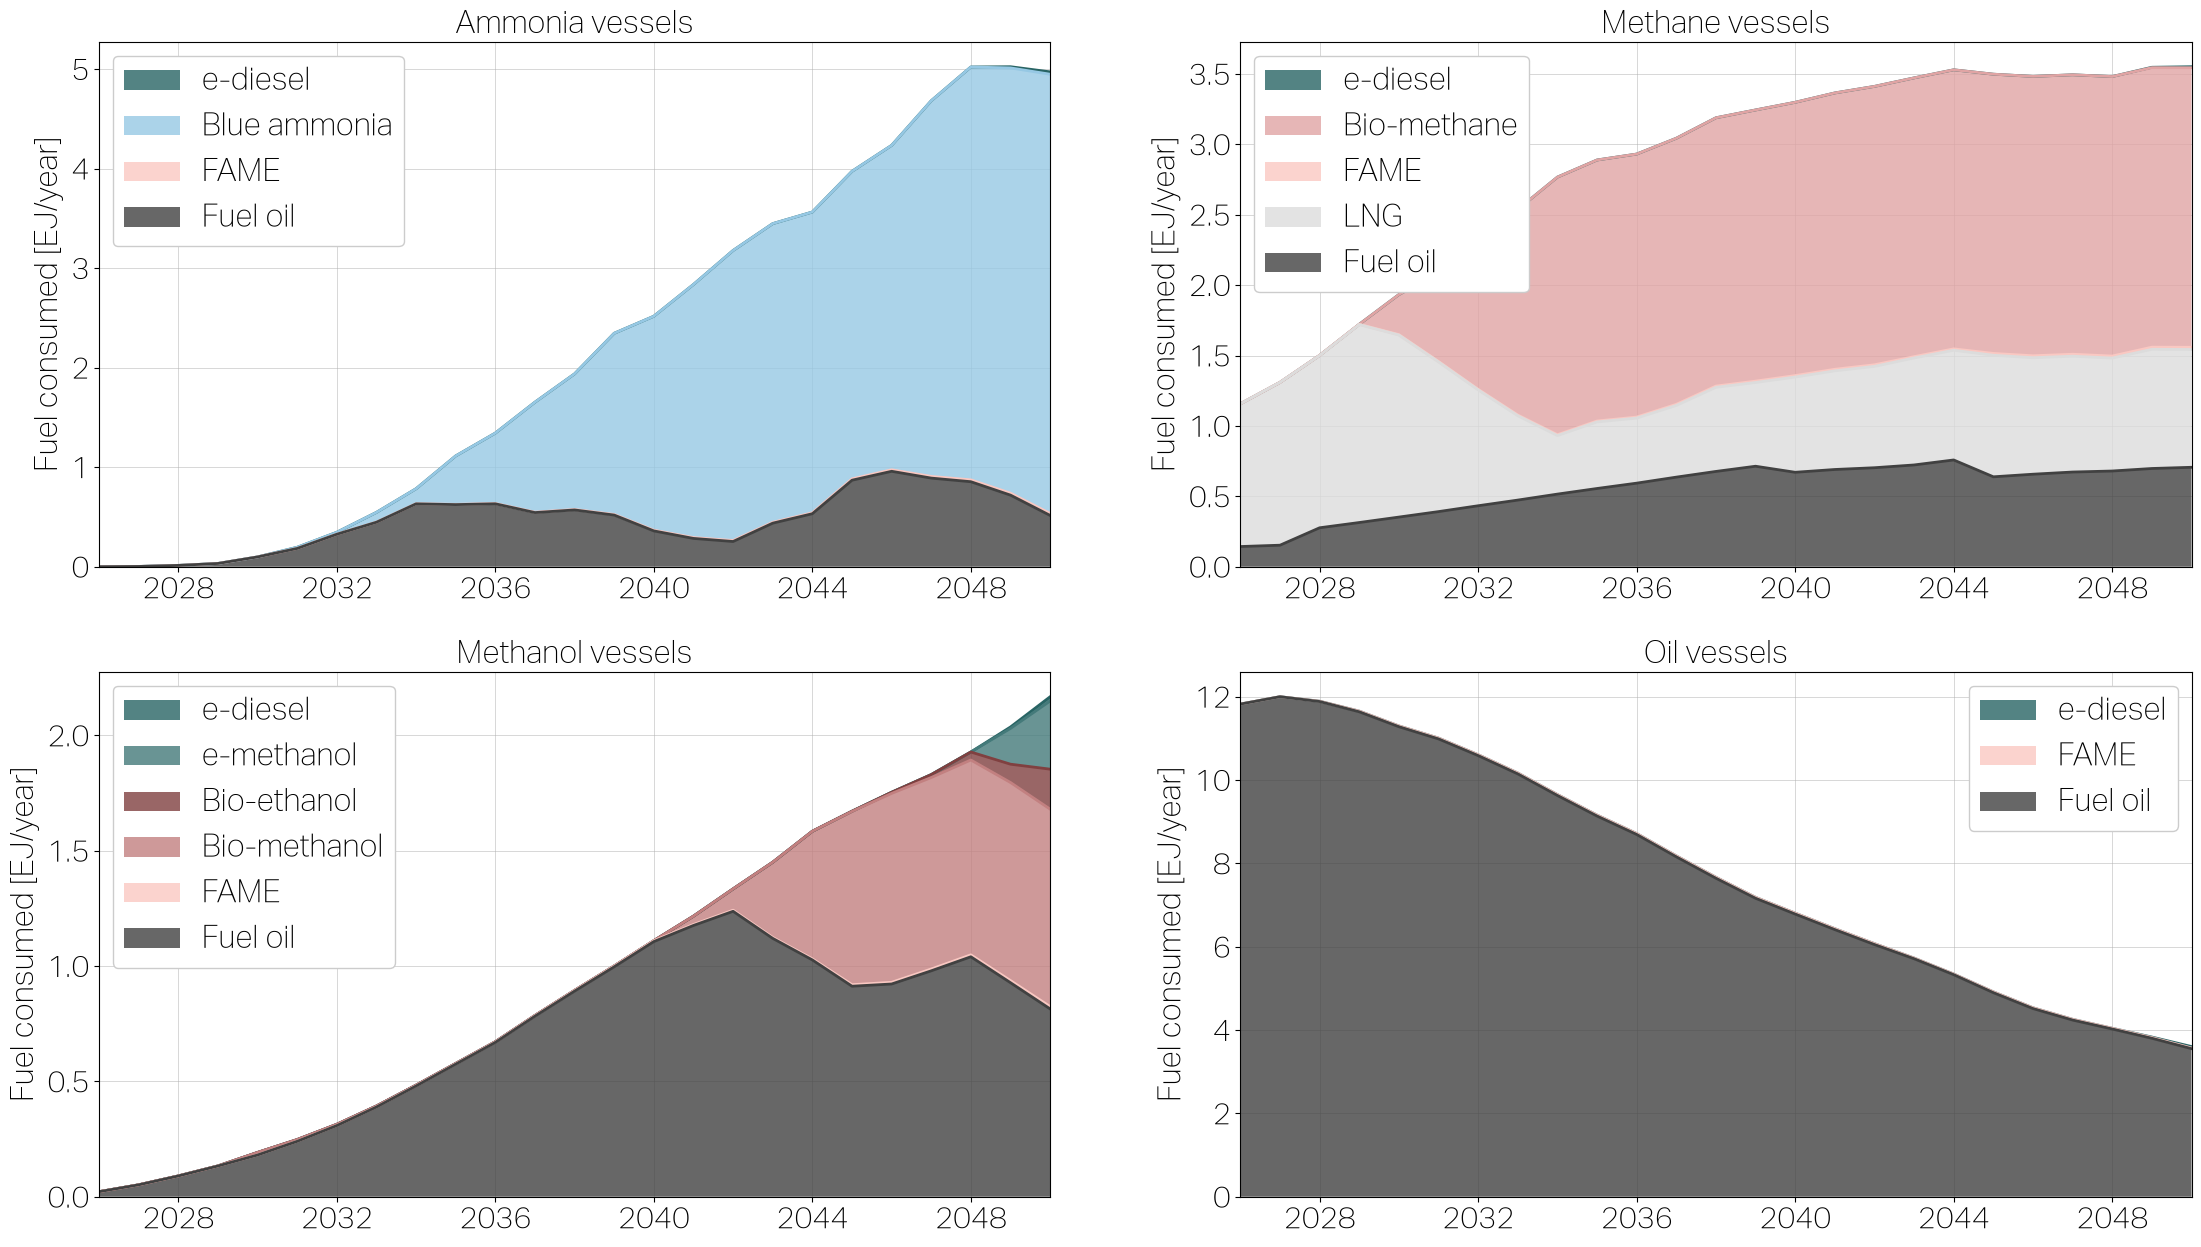

### Fuel type supply demand

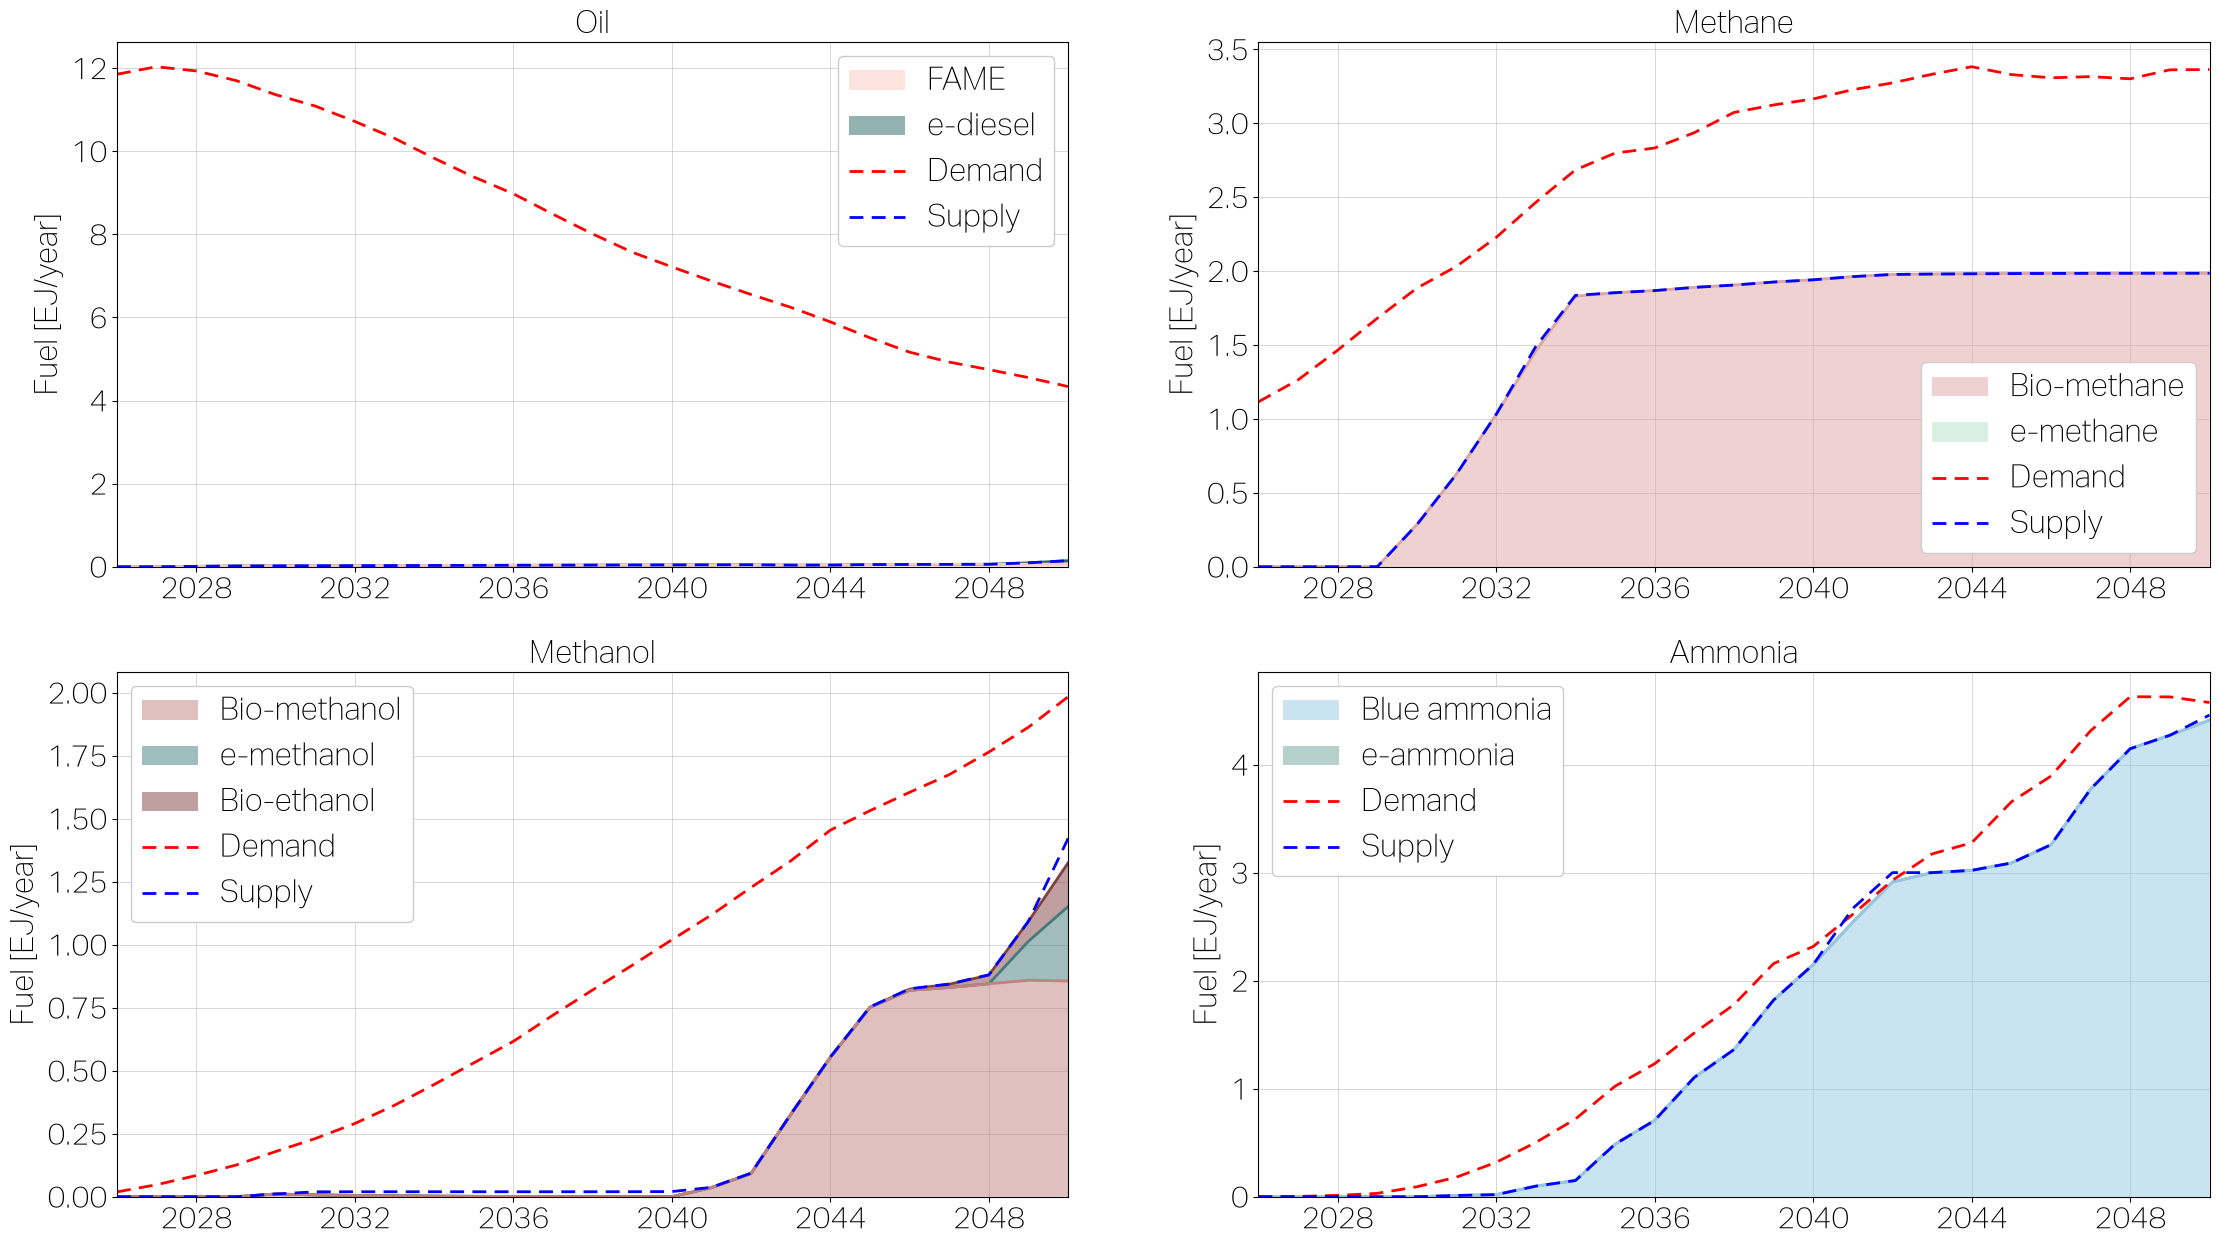

### Global emission absolute

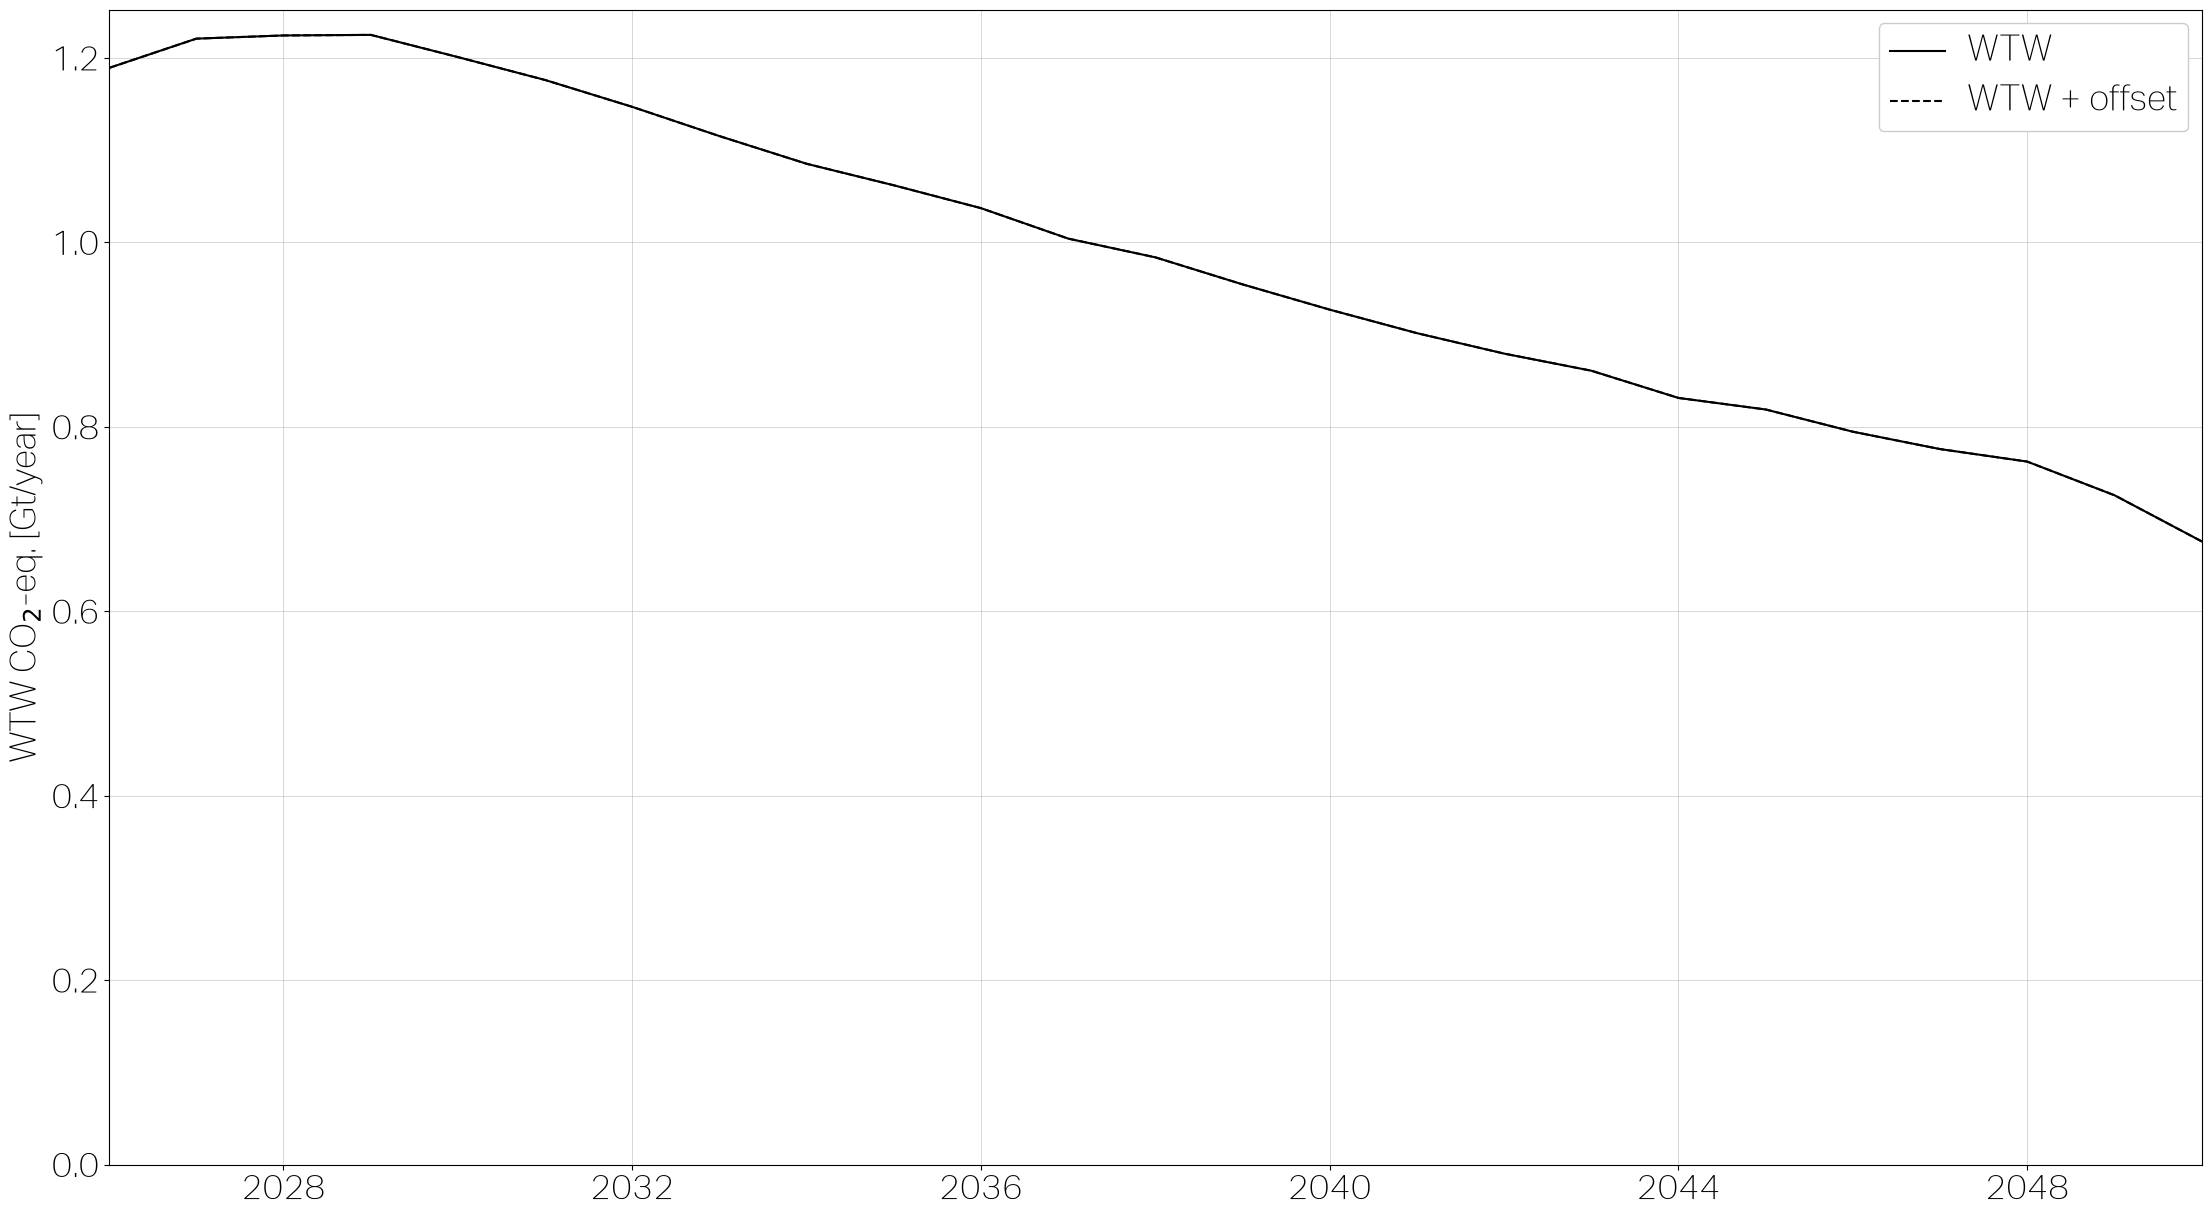

### Global energy saving

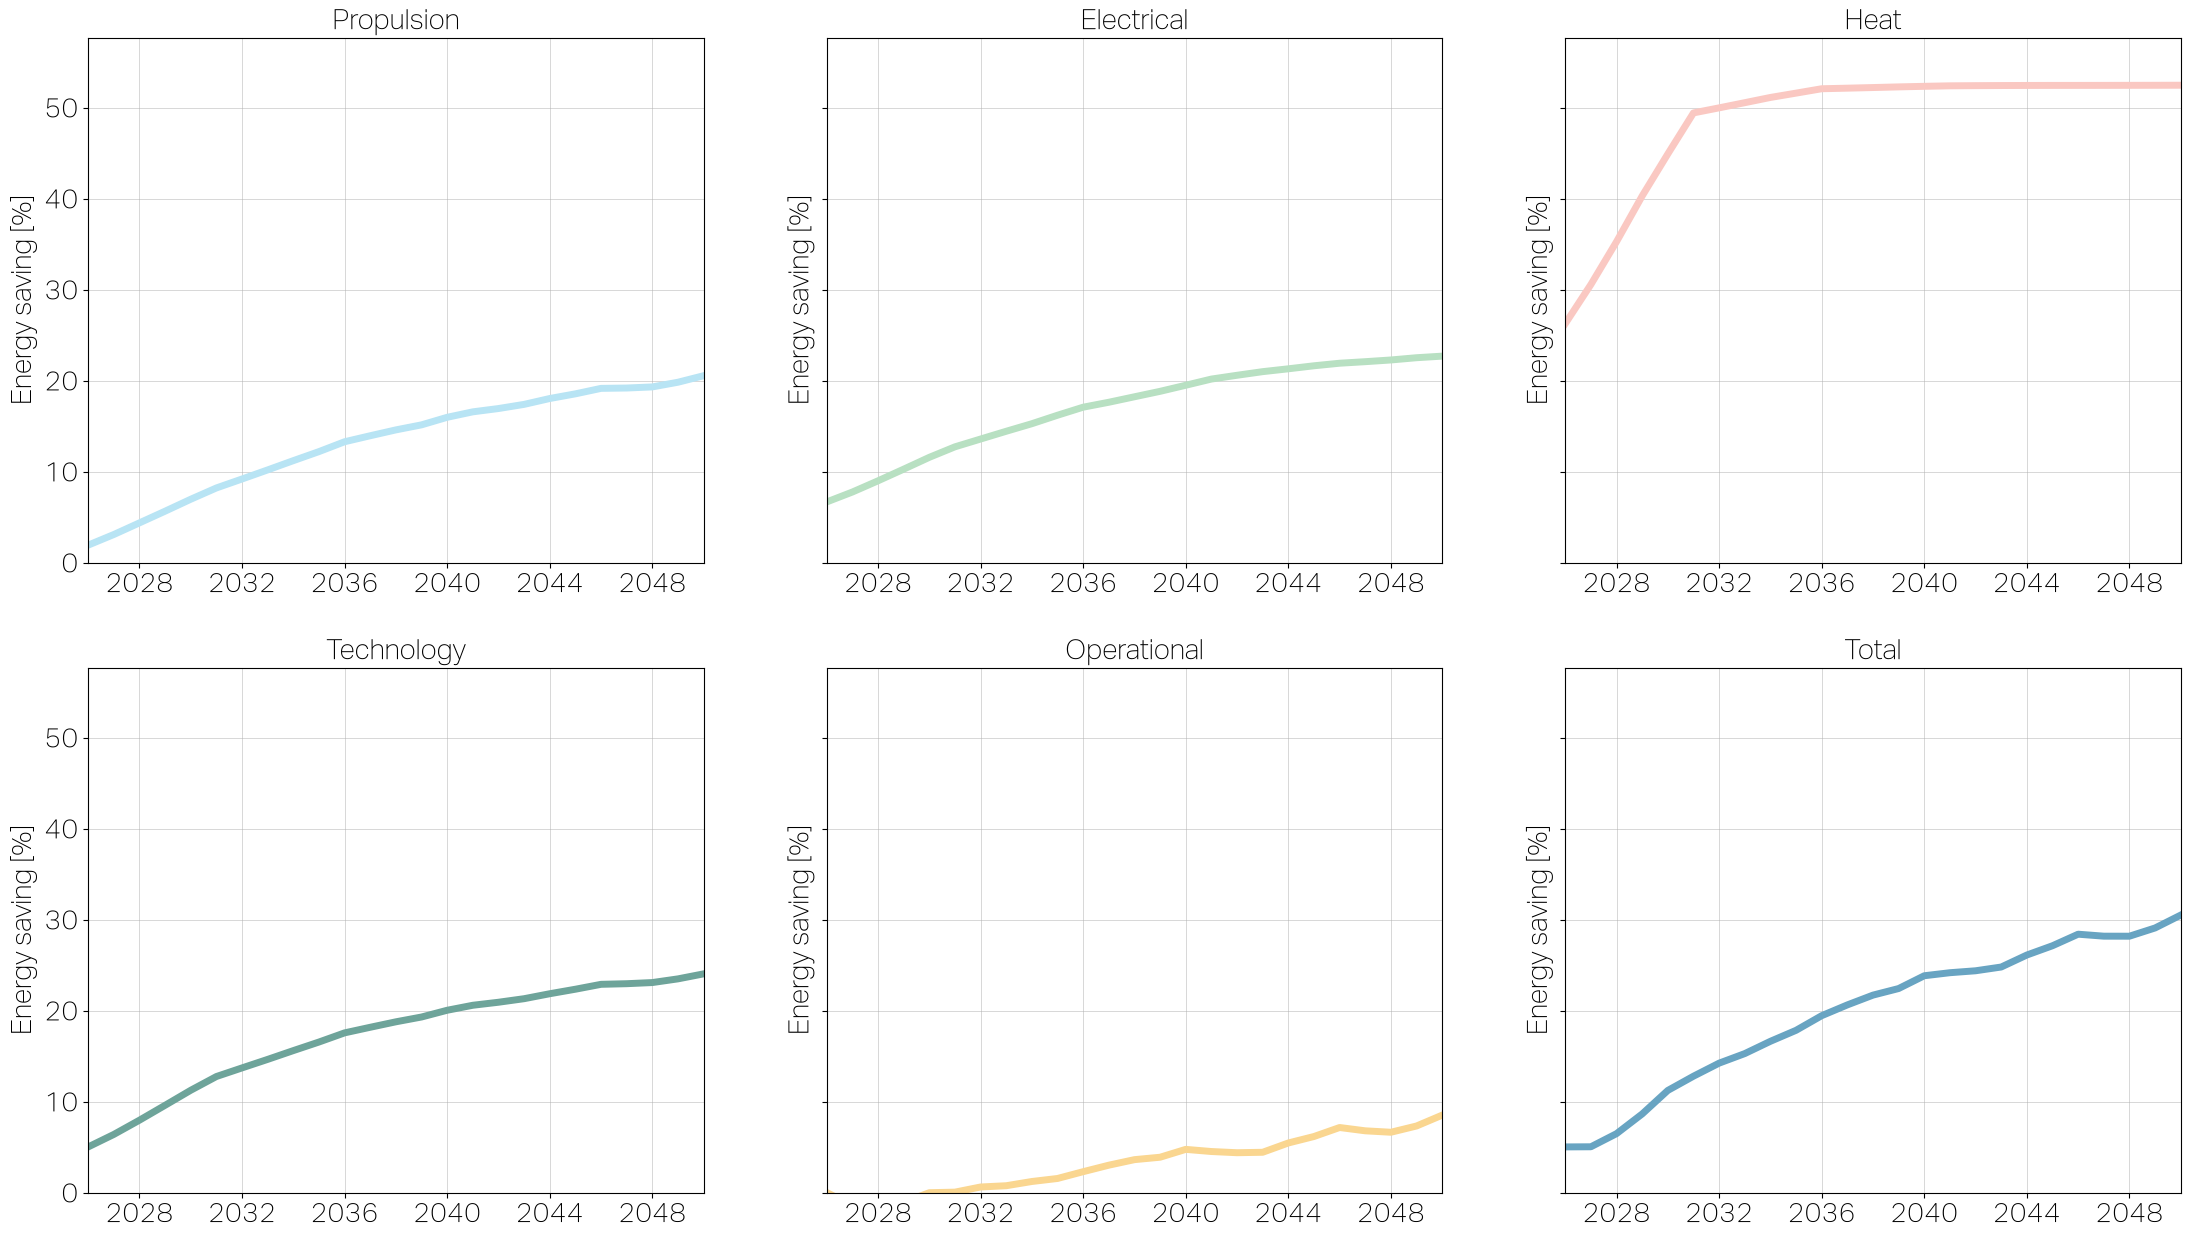

### Global fuel consumed

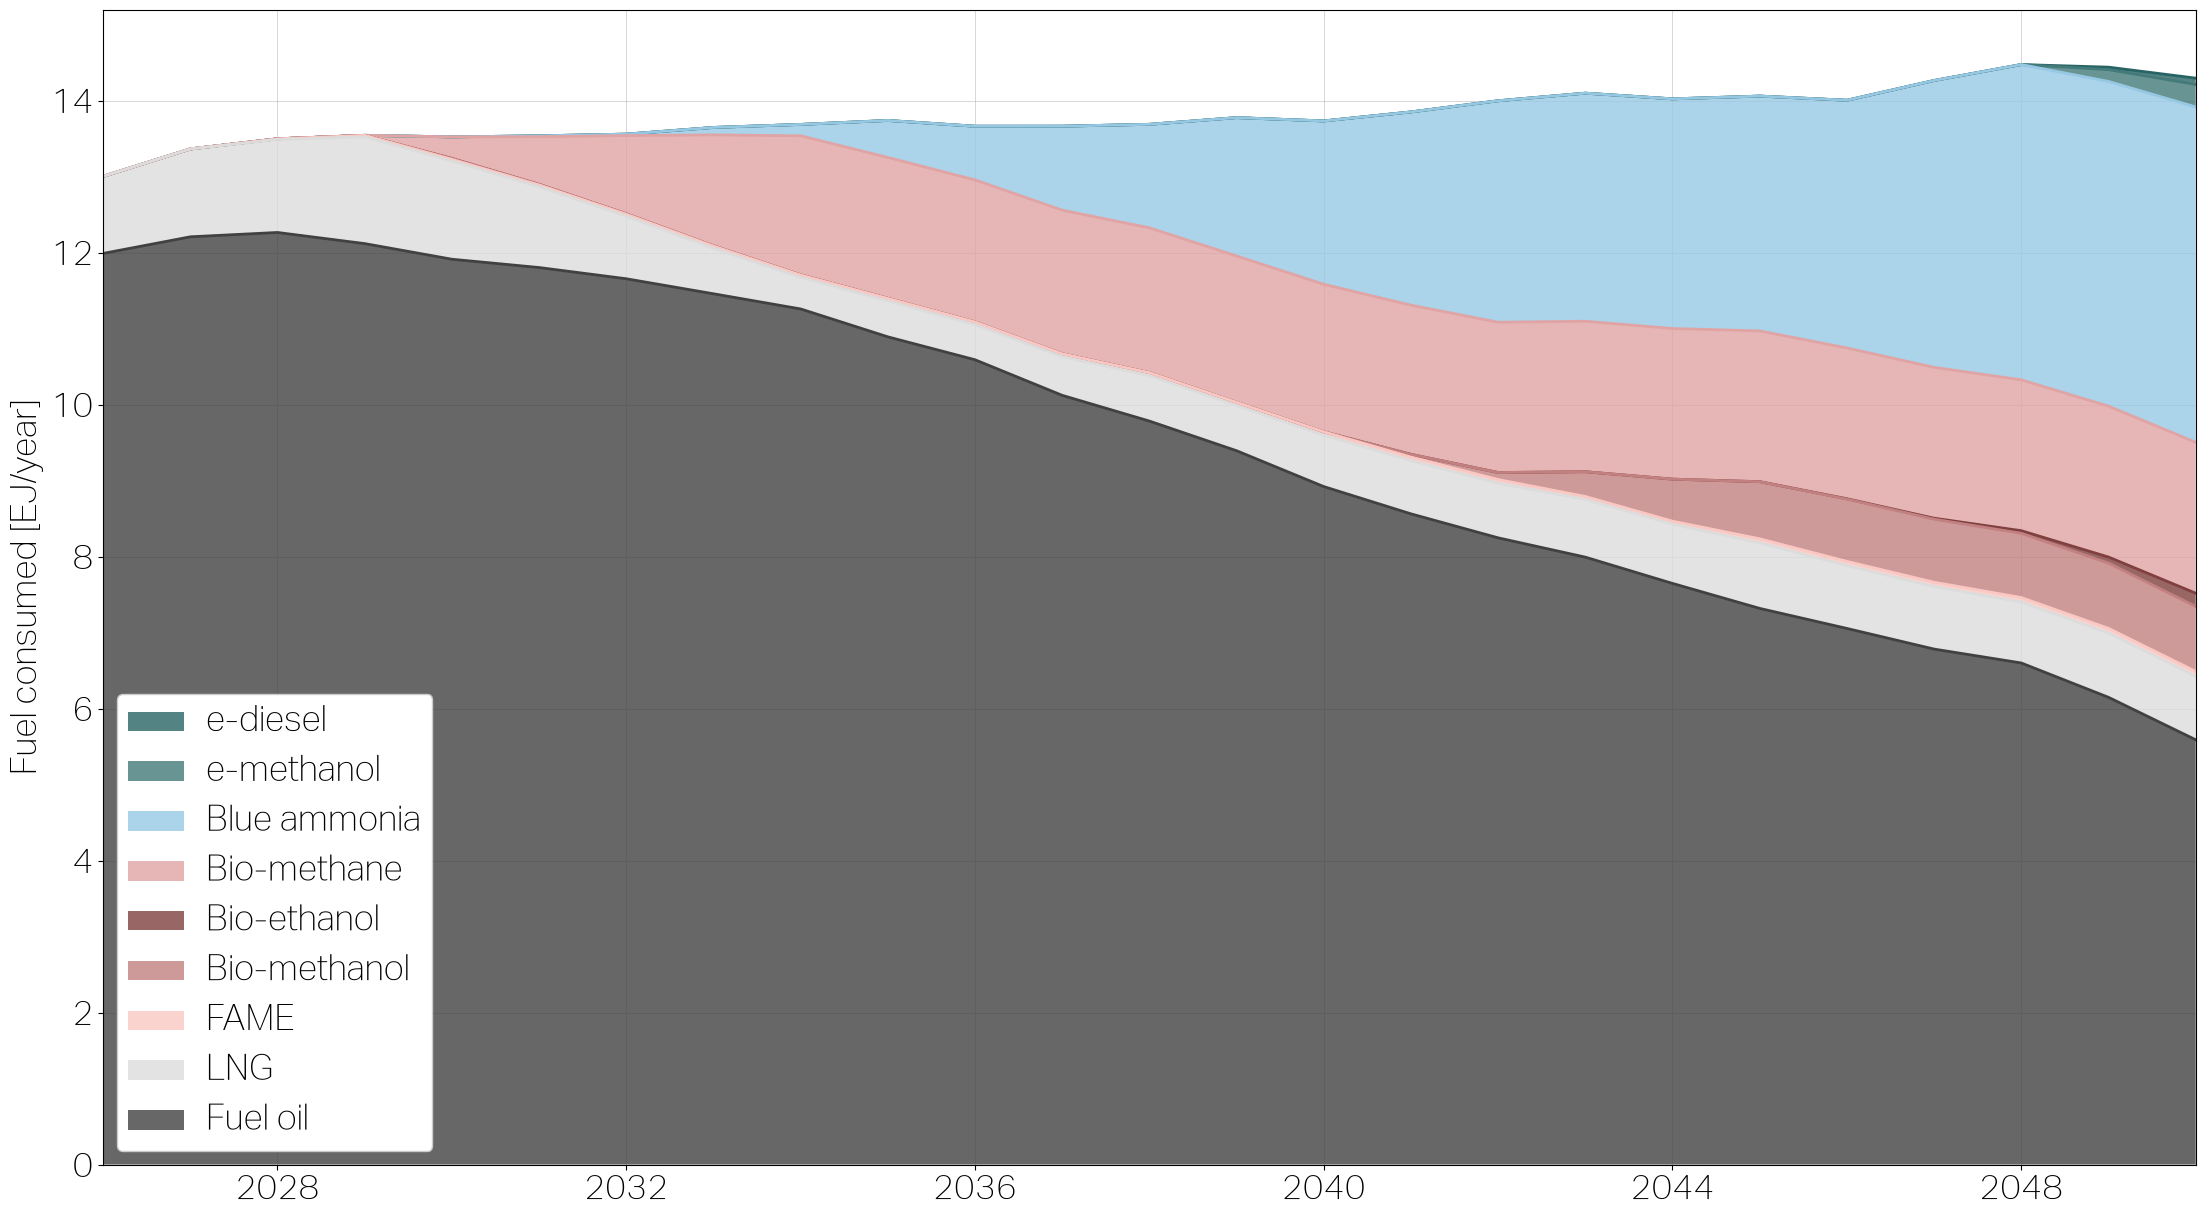

### Global installed power

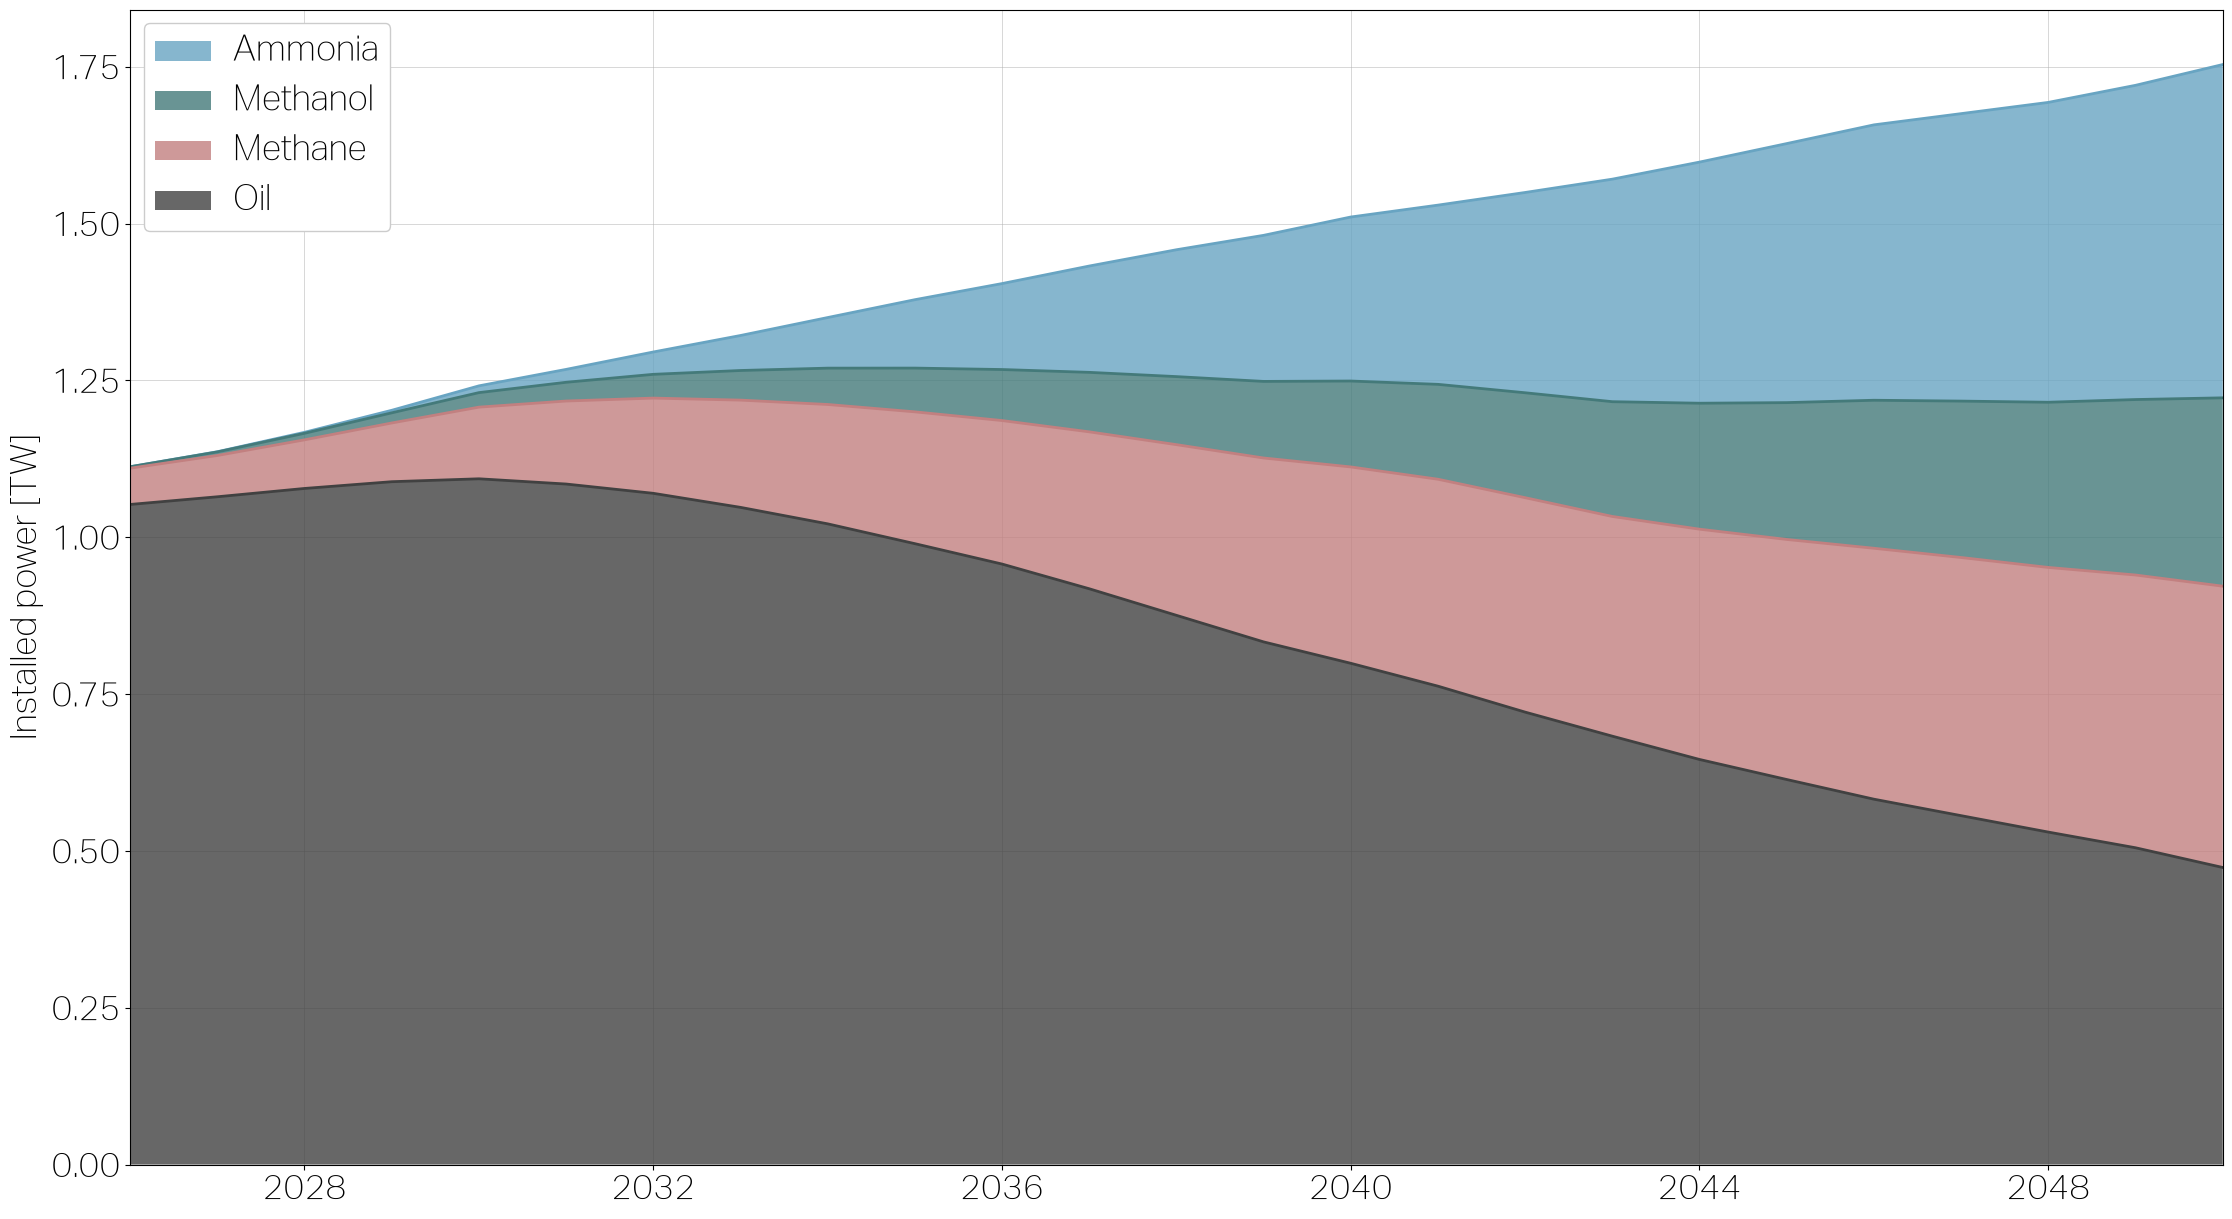

### Producer development

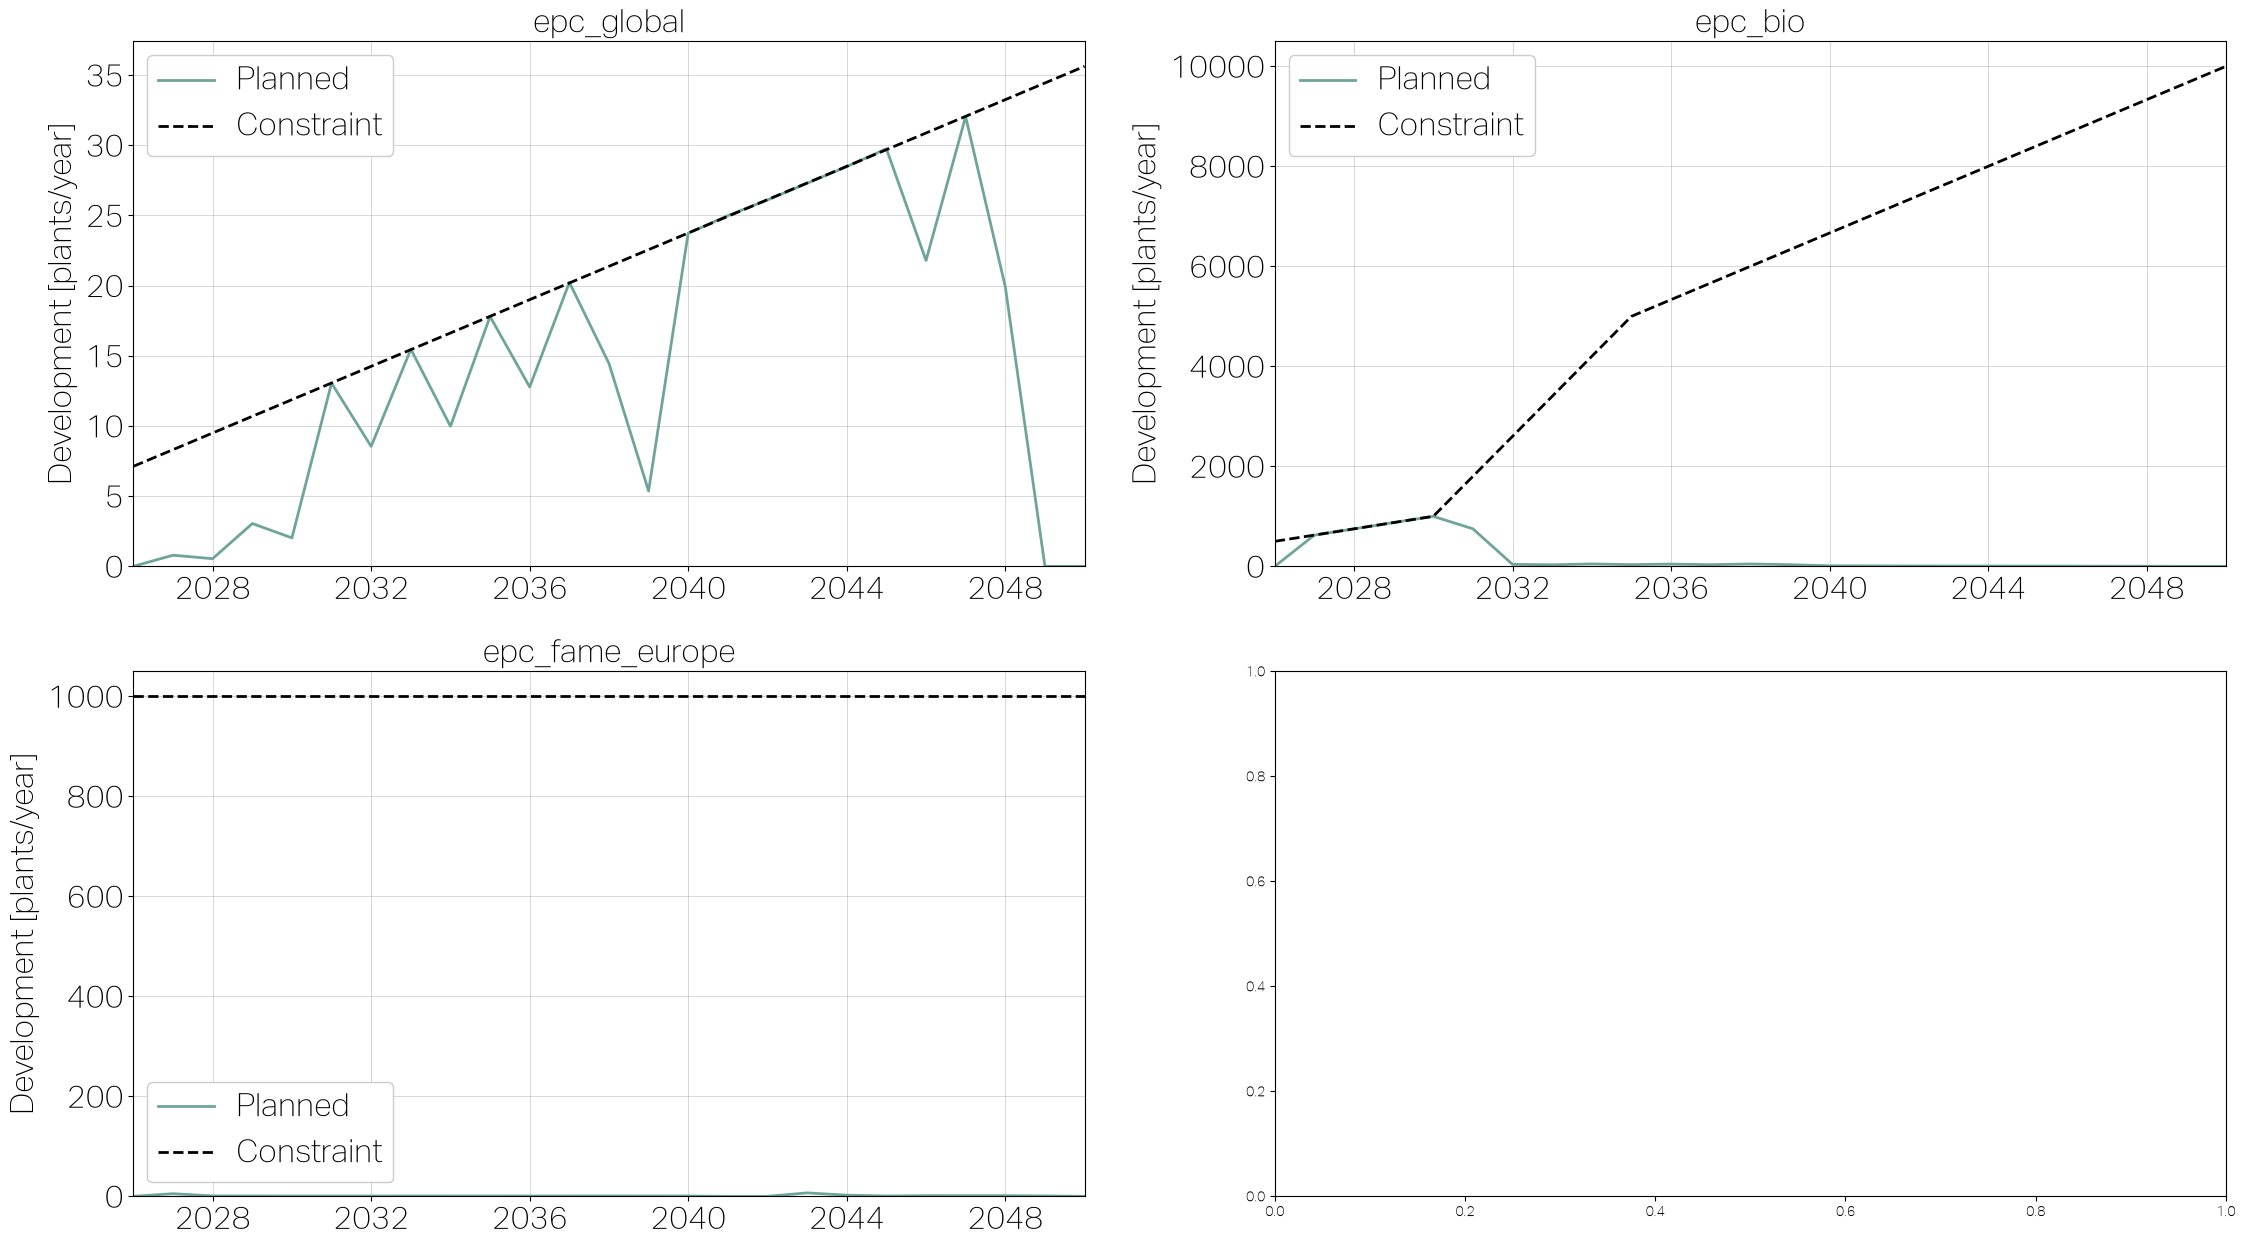

### Regulation compliance eu ets

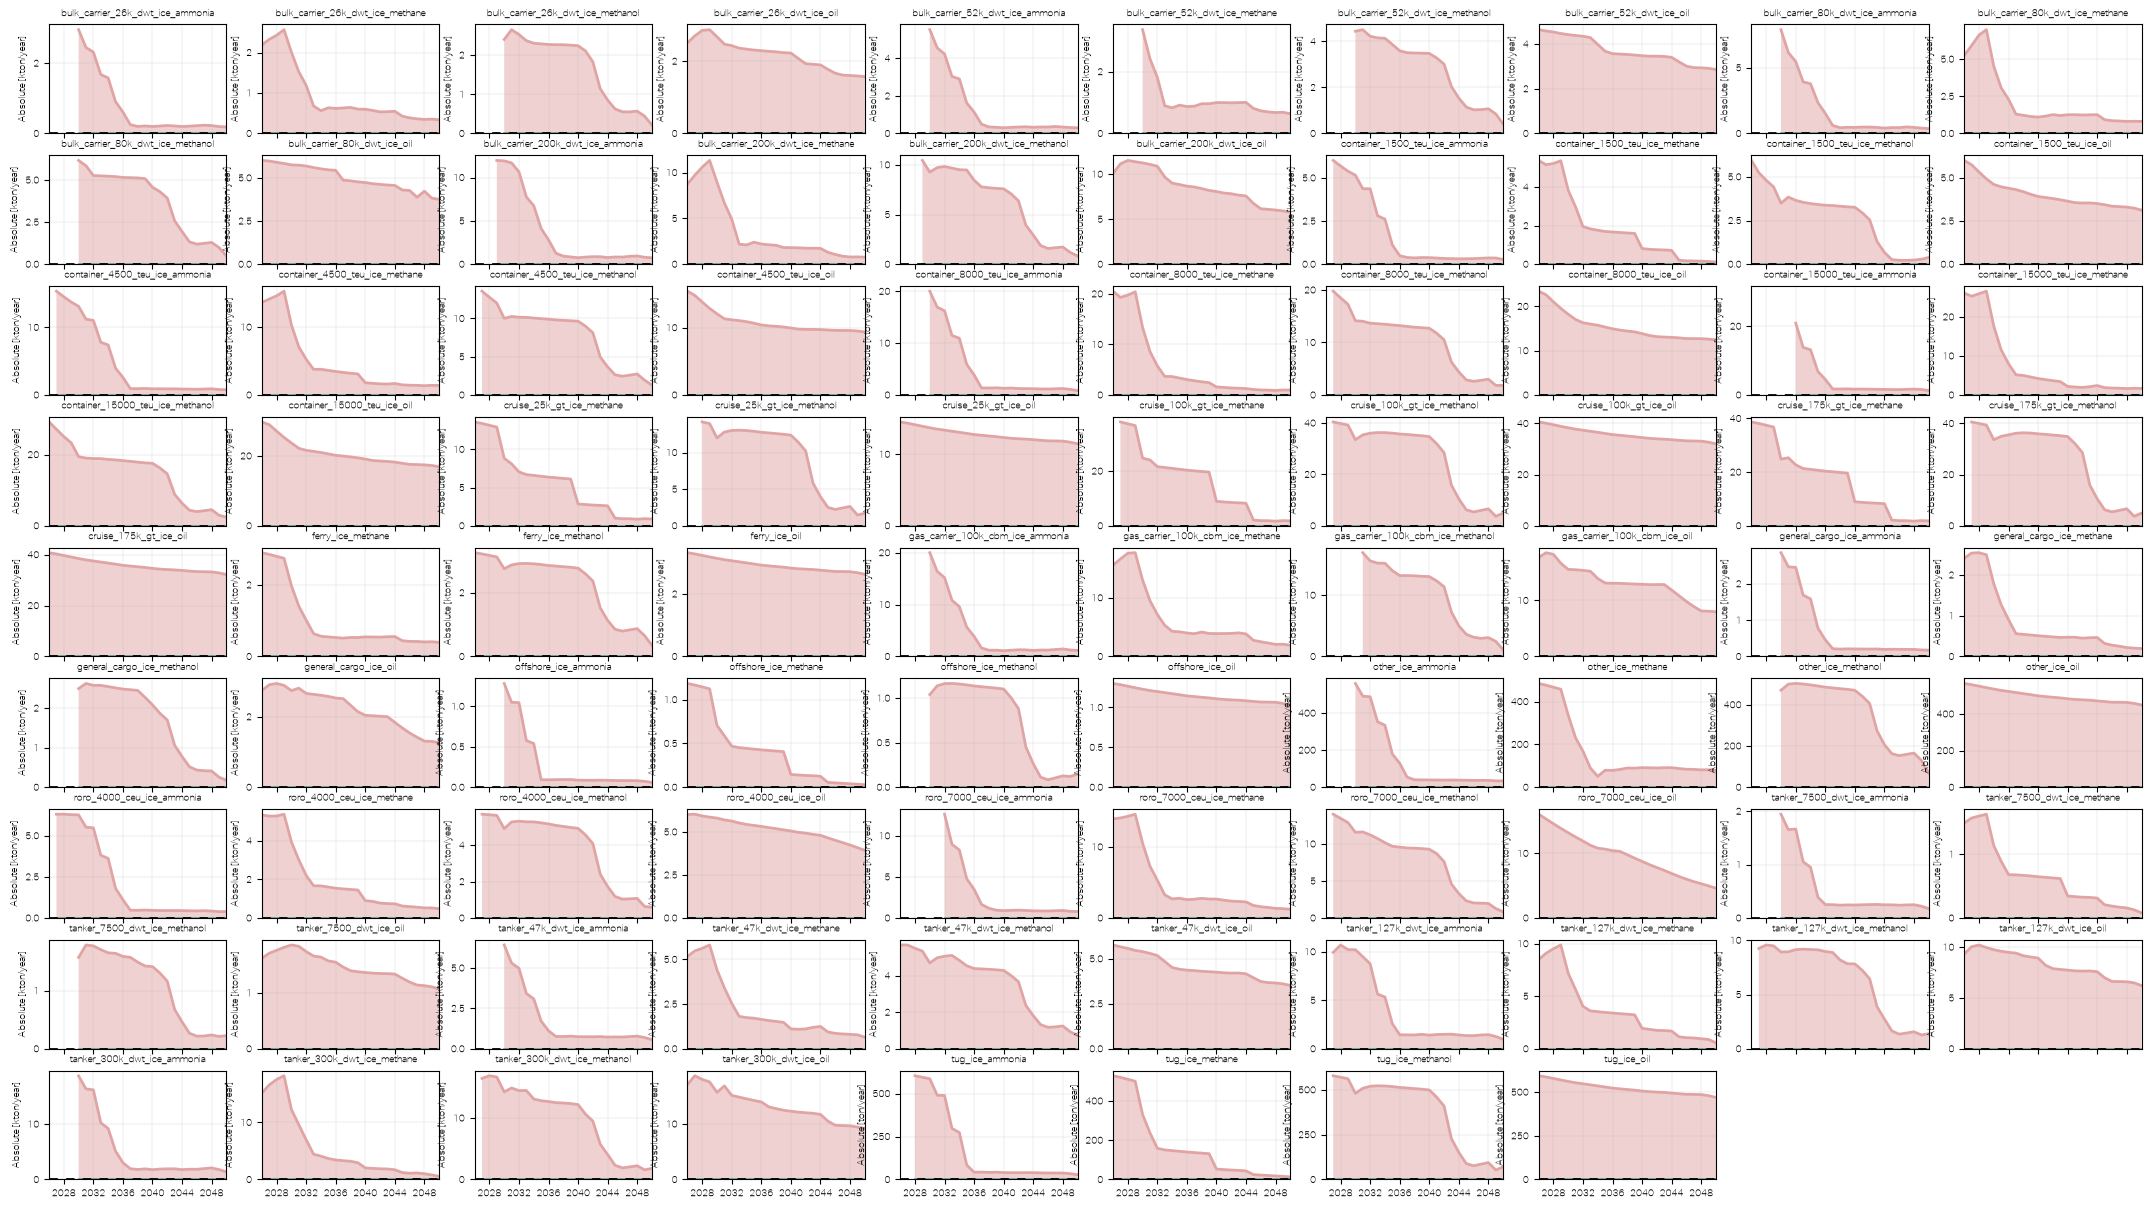

### Regulation compliance fuel eu

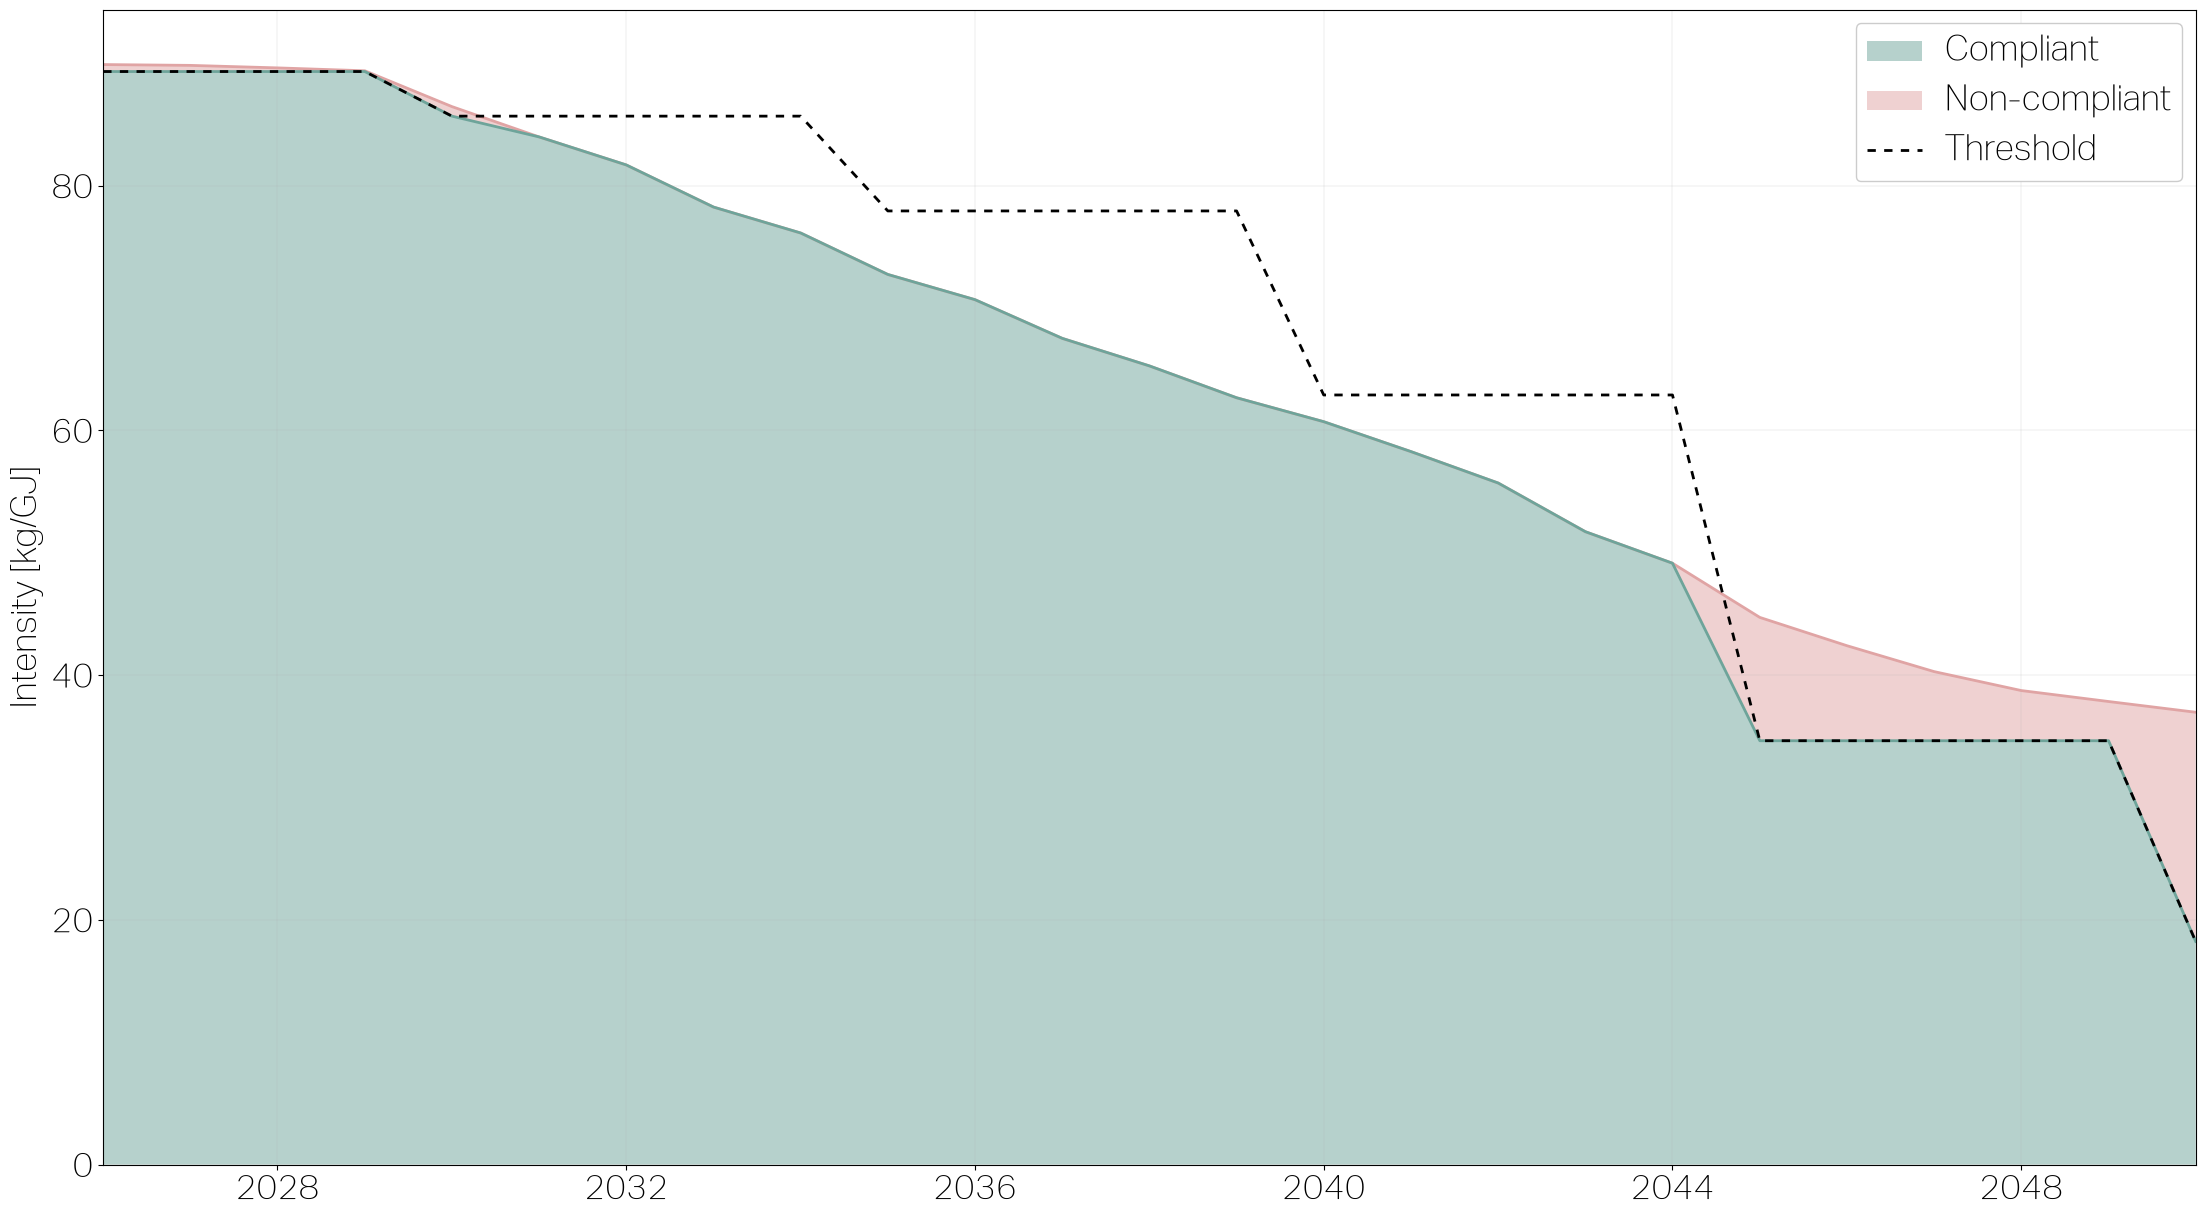

### Regulation compliance gfs

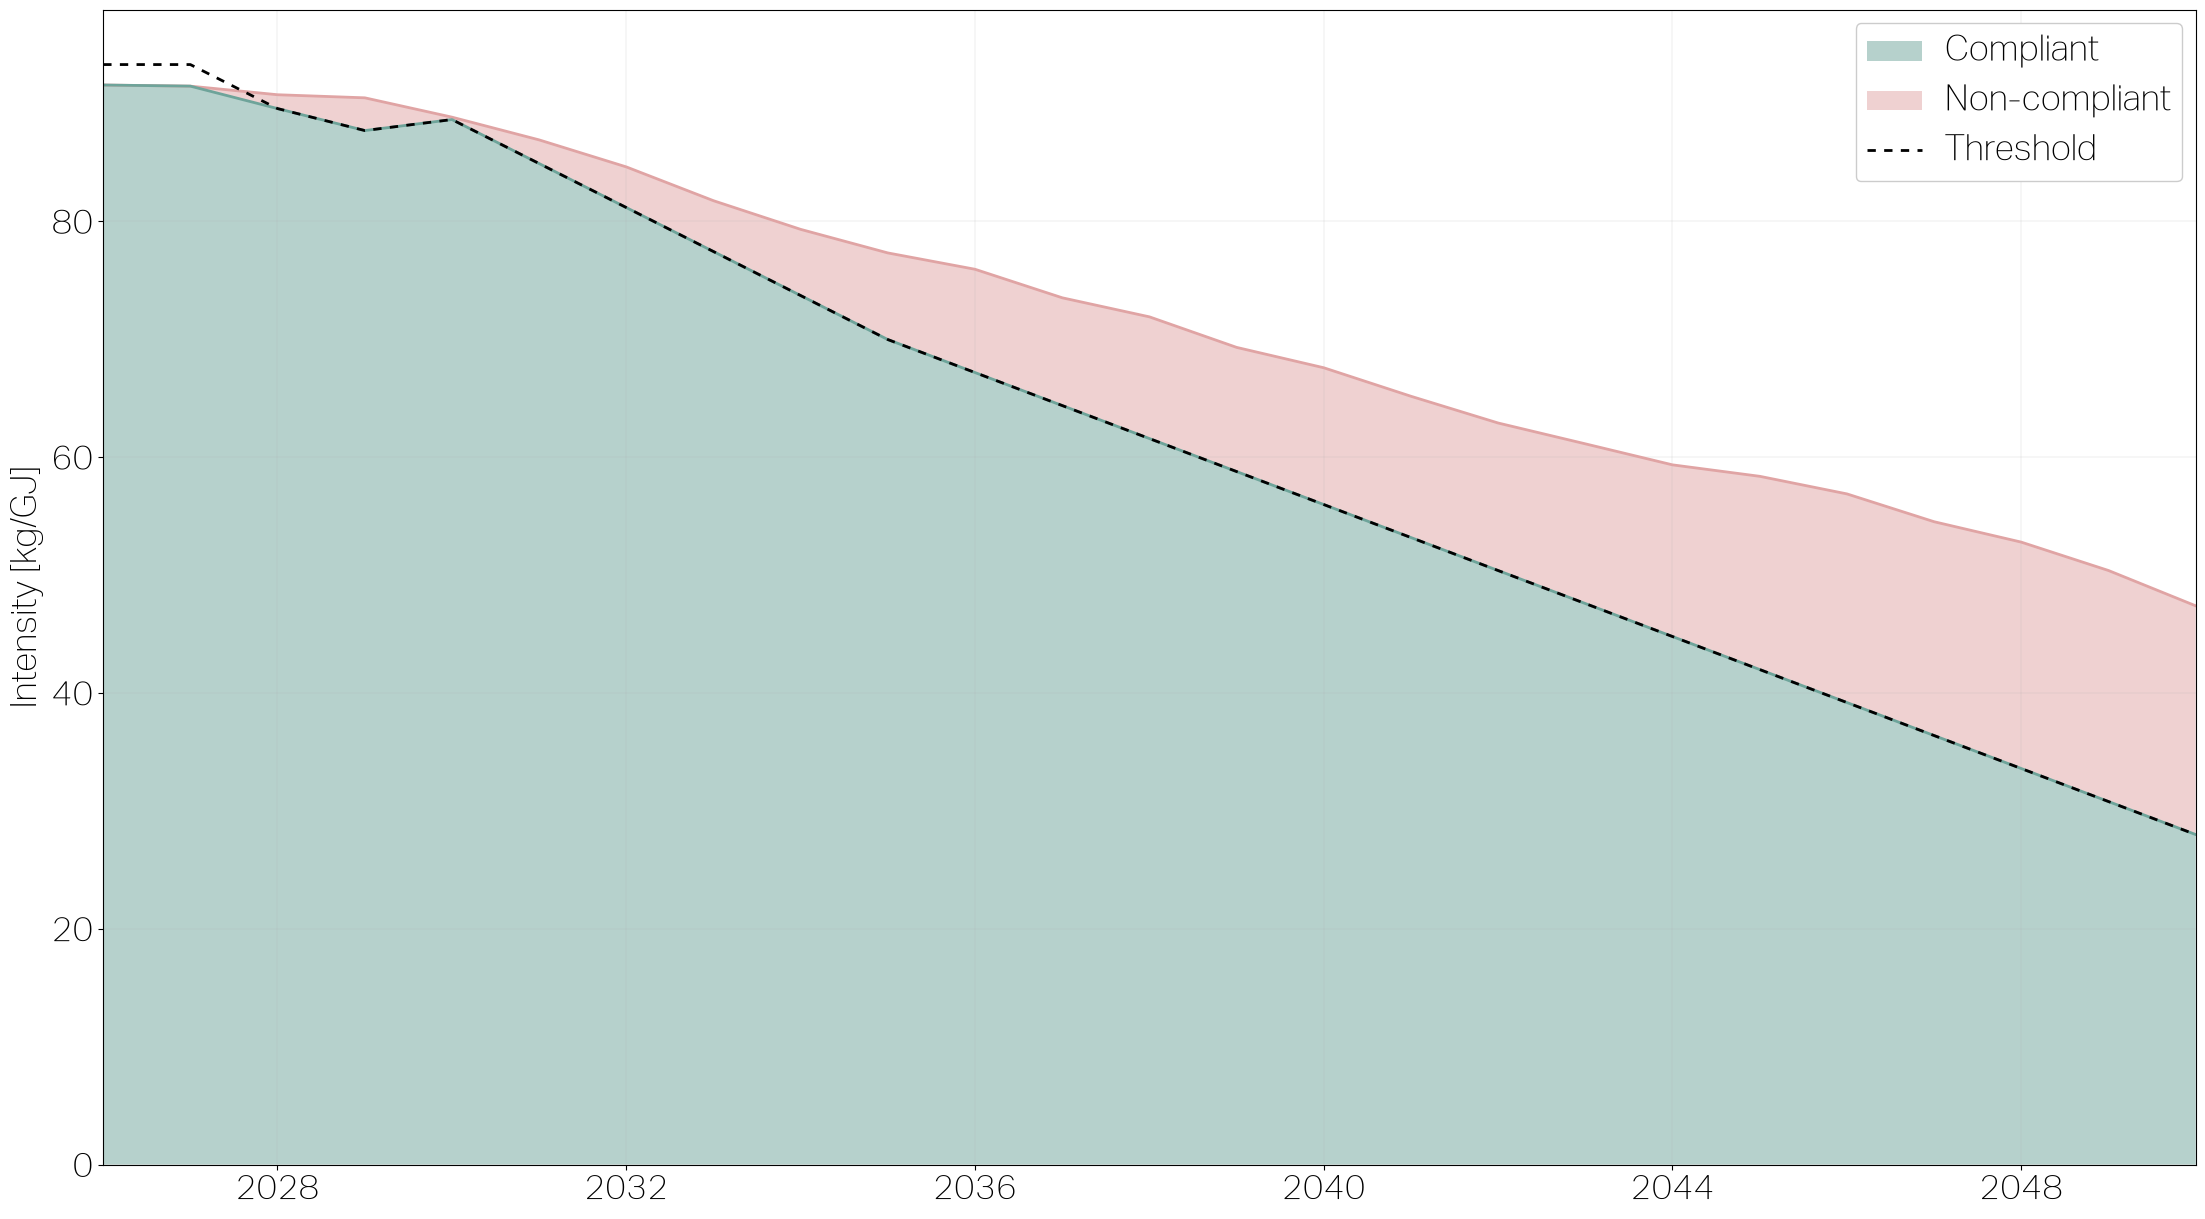

### Regulation flexibility cost fuel eu

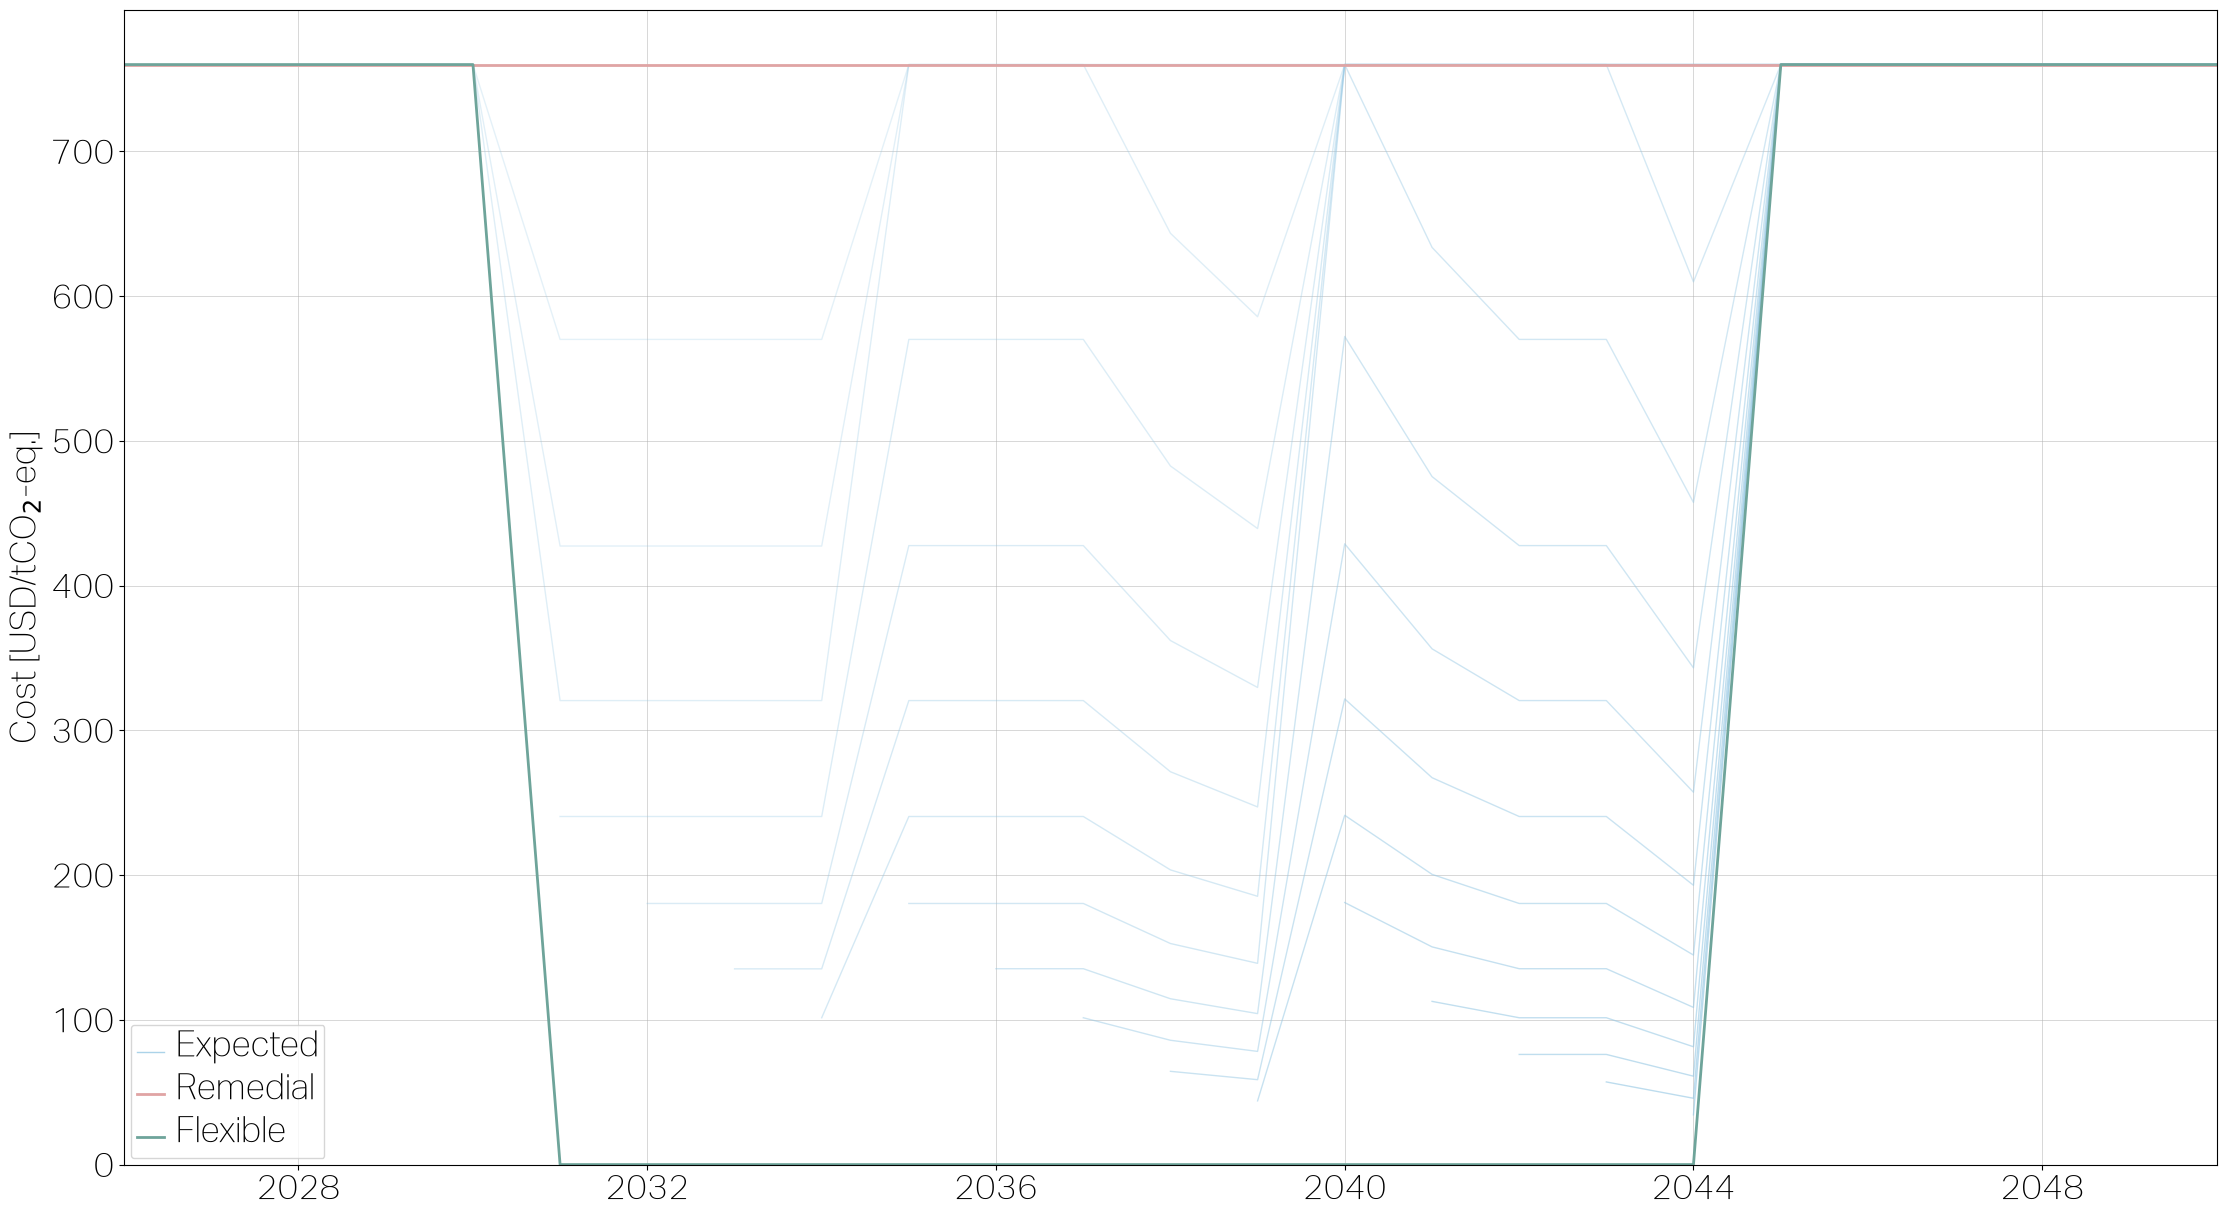

### Regulation flexibility cost gfs

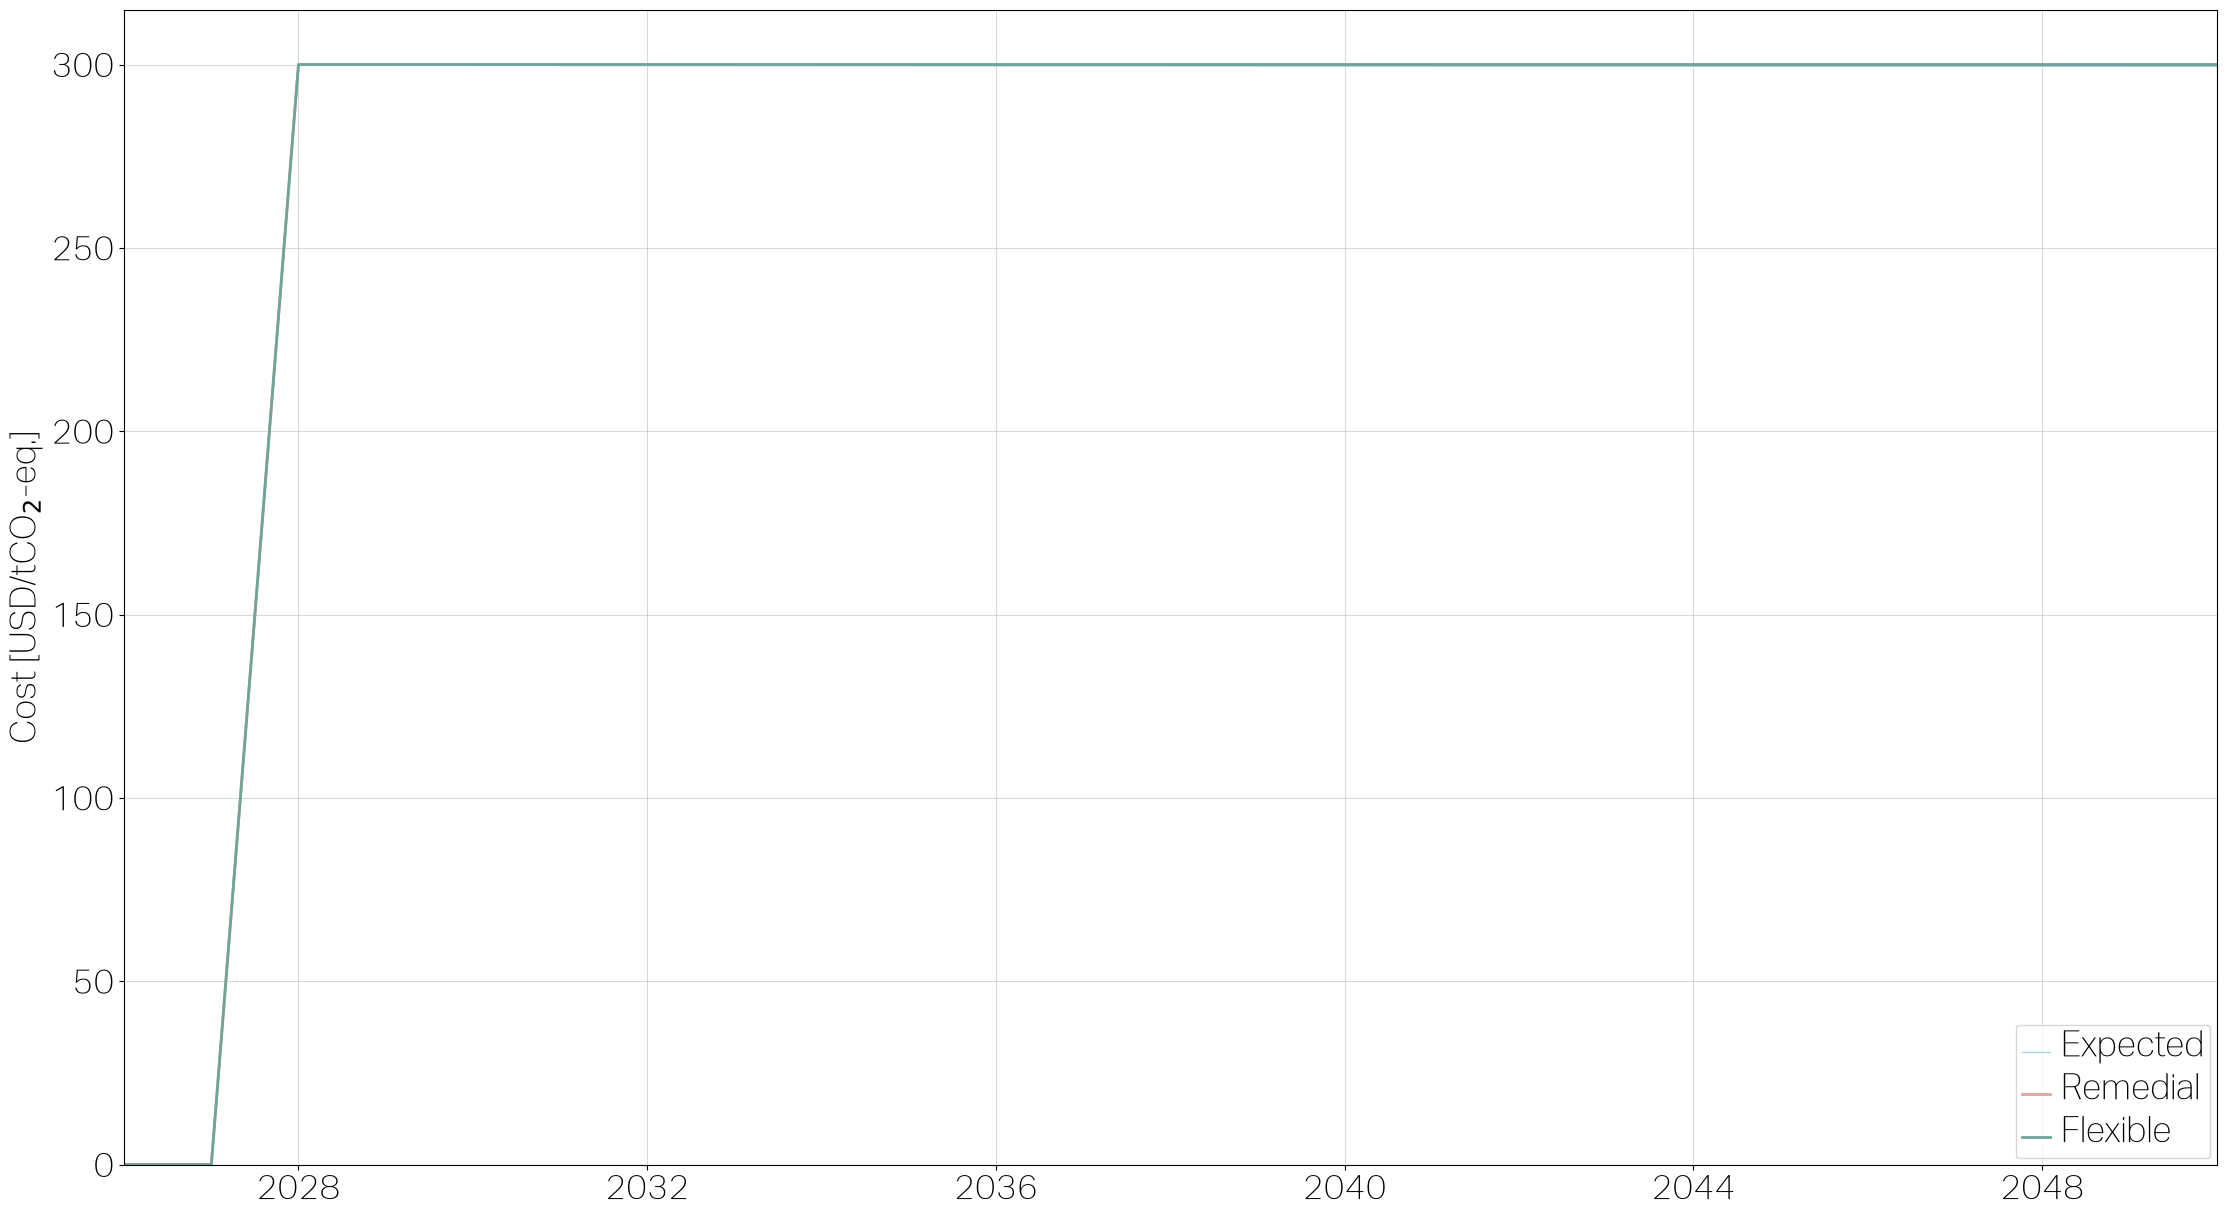

In [3]:
# @title Show the output plots
import glob
from IPython.display import Image, Markdown, display

plots_dir = f"simulations/scenarios/{scenario}/plots"
plot_files = sorted(glob.glob(f"{plots_dir}/*.png"))

if not plot_files:
    print(f"No .png plots found in {plots_dir} -- check what Navigate actually wrote there:")
    for root, dirs, files in os.walk(f"simulations/scenarios/{scenario}"):
        for fn in files:
            print(os.path.join(root, fn))
else:
    for p in plot_files:
        title = os.path.splitext(os.path.basename(p))[0].replace("_", " ").capitalize()
        display(Markdown(f"### {title}"))
        display(Image(filename=p))


## Inspect the exported assumptions

The `-e` flag exported the assumptions used for this run to Excel. Let's preview the sheet names and a first look at the data.

In [4]:
# @title List the exported assumption files
import glob
import pandas as pd

excel_files = glob.glob(f"simulations/scenarios/{scenario}/**/*.xlsx", recursive=True)
print("Exported Excel files found:")
for f in excel_files:
    print(" -", f)

workbook = f"simulations/scenarios/{scenario}/{scenario}_assumptions.xlsx"
if os.path.exists(workbook):
    xls = pd.ExcelFile(workbook)
    print("Sheets in", workbook, ":", xls.sheet_names)
    display(xls.parse(xls.sheet_names[0]).head())


Exported Excel files found:
 - simulations/scenarios/basecase_mid_regulation\basecase_mid_regulation_assumptions.xlsx
 - simulations/scenarios/basecase_mid_regulation\plots\basecase_mid_regulation_report_default.xlsx


Sheets in simulations/scenarios/basecase_mid_regulation/basecase_mid_regulation_assumptions.xlsx : ['Assumptions', 'Curves & Forecasts', 'Surfaces & Timetables']


,Node,Name,Parameter,Assignment Date,Value,Unit
0,Converter,propulsion_ice_ammonia_bulk_carrier_26k_dwt,CAPEX,2026-01-01,"Forecast(""propulsion_ammonia_capex"")",USD/MW
1,Converter,propulsion_ice_ammonia_bulk_carrier_26k_dwt,OPEX,2026-01-01,"Forecast(""propulsion_ammonia_opex"")",USD/MW/year
2,Converter,propulsion_ice_ammonia_bulk_carrier_26k_dwt,Replacement,2026-01-01,1,fraction
3,Converter,propulsion_ice_ammonia_bulk_carrier_26k_dwt,PowerCapacity,2026-01-01,6.6,MW
4,Converter,propulsion_ice_ammonia_bulk_carrier_26k_dwt,MinimumLoad,2026-01-01,0.2,fraction


## Compare the three scenarios

The plots above are one scenario at a time. This last section puts all three
next to each other.

It reads each run's `plot_data.pkl` rather than its exported PNGs. That is the
solved model itself — nodes, profiles and the dateline — so the same metric can
be recomputed identically for every scenario, and nothing has to be re-solved.
It is also the only view that works for a run that solved but whose plots were
not exported.

The three decks differ only in their regulation lines, so everything below is
attributable to regulatory stringency alone.

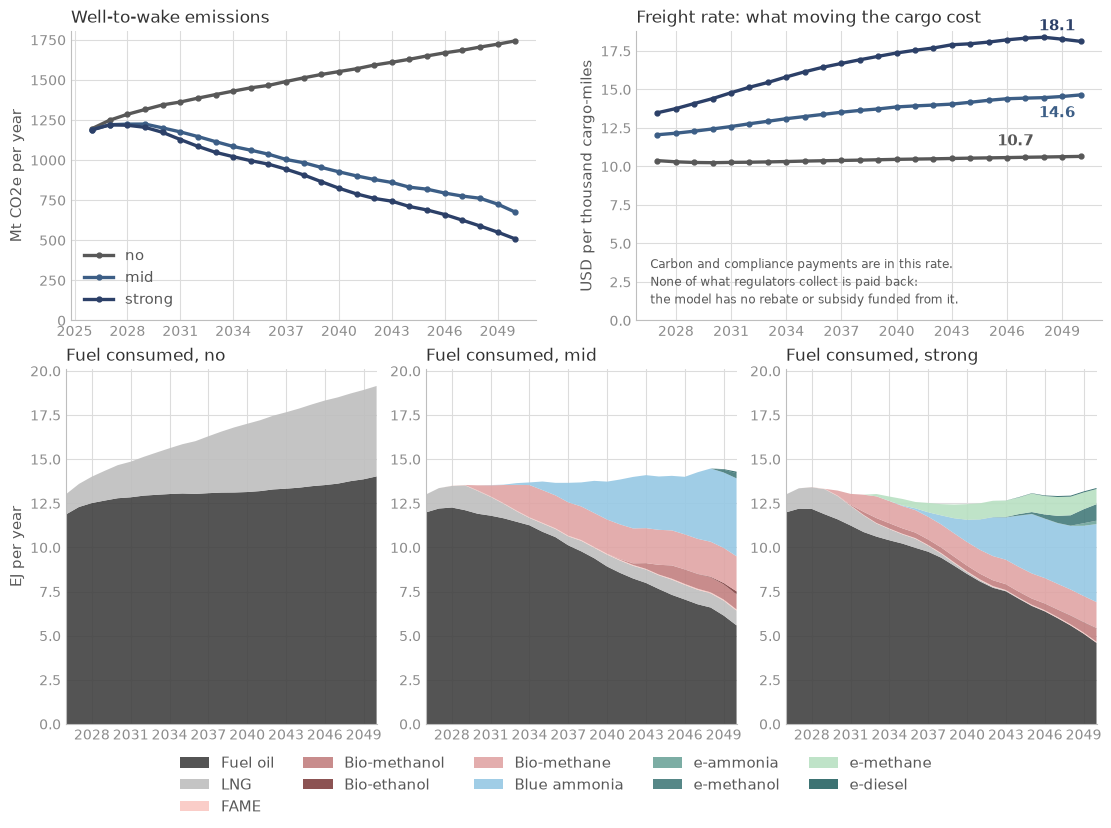

  scenario         WTW 2026   WTW 2050   cumulative  alt fuel 2050      freight 2050
                      Mt/yr      Mt/yr           Mt              %  USD/k cargo-mile
  no                  1,197      1,744       37,569            0.0              10.7
  mid                 1,189        676       24,580           55.0              14.6
  strong              1,189        509       22,433           65.6              18.1


In [5]:
# @title Figure: compare the three scenarios
import gzip
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Every run leaves its solved model on disk as a gzipped pickle, so comparing
# them costs nothing to redo. It is also the only view that works for every
# scenario: a run that solved but did not export its PNGs still has one of these.
COMPARE = ["basecase_no_regulation", "basecase_mid_regulation",
           "basecase_strong_regulation"]
SHORT = {s: s.replace("basecase_", "").replace("_regulation", "") for s in COMPARE}
FOSSIL = {"fossil_fuel_oil", "liquefied_natural_gas"}


def solved_model(scenario):
    with gzip.open(f"simulations/scenarios/{scenario}/plot_data.pkl", "rb") as fh:
        return pickle.load(fh)


def num(x):
    return np.nan_to_num(np.asarray(x, dtype=float))


solved = {}
for _s in COMPARE:
    if Path(f"simulations/scenarios/{_s}/plot_data.pkl").exists():
        solved[_s] = solved_model(_s)
    else:
        print(f"{_s}: no plot_data.pkl yet - run the cell above first")

if not solved:
    raise RuntimeError("no solved scenarios found; run them above before comparing")

# --- aggregate over all 23 fleets, the way notebook 3 does ------------------
# Same four series, so the two comparison figures can be read the same way:
# emissions, the fuel mix year by year, what the trade cost, and the share of
# alternatives at the end.
def fleet_cargo_miles(fleet):
    """Cargo-miles the whole fleet sailed each year: per-ship cargo-miles times hulls."""
    hulls = fleet.profile.get_existing_vessels()
    return sum(np.nan_to_num(np.asarray(hulls[v.get_name()], dtype=float))
               * np.nan_to_num(np.asarray(v.profile.get_cargo_miles(), dtype=float))
               for v in fleet.get_vessels())


cases = {}
for s, d in solved.items():
    years = d.get_dateline().astype("datetime64[Y]").astype(int) + 1970
    total = np.zeros(len(years))
    rate_x_miles, miles = np.zeros(len(years)), np.zeros(len(years))
    by_year_raw, last_alt, last_all = {}, 0., 0.
    for fleet in d.nodes.fleets.values():
        total = total + num(fleet.profile.get_total_equivalent_WTW())
        cargo_miles = fleet_cargo_miles(fleet)
        rate_x_miles = rate_x_miles + cargo_miles * num(
            fleet.profile.get_instantaneous_freight_rate())
        miles = miles + cargo_miles
        for fuel, series in fleet.profile.get_consumed_energy().items():
            values = num(series)
            by_year_raw[fuel] = by_year_raw.get(fuel, np.zeros(len(years))) + values
            last_all += float(values[-1])
            if fuel not in FOSSIL:
                last_alt += float(values[-1])
    cases[s] = {
        "years": years,
        "wtw": total / 1e6,                                # Mt CO2e per year
        # GJ -> EJ, stacked in Navigate's own fuel order
        "by_year": {f: by_year_raw[f] / 1e9 for f in fuel_sorted(by_year_raw)
                    if by_year_raw[f].sum() > 0},
        # the model's own instantaneous rate, weighted by the cargo-miles each
        # fleet moved, in the unit Navigate's fleet_investment_metric plot uses
        "freight": 1e3 * np.divide(rate_x_miles, miles,
                                   out=np.zeros_like(miles), where=miles > 0),
        "alt_last": 100. * last_alt / last_all if last_all else 0.,
    }

# One colour per scenario, an ordered grey-to-blue ramp shared with the
# forecast chart further up, and deliberately not fuel colours: the panels
# below stack fuels right beside them.
order = [s for s in COMPARE if s in cases]
TITLE, LABEL, TICK_SIZE = 12.5, 10.5, 10

# Session 1's layout, drawn at the width the page shows it so the type stays
# readable: emissions and cost on top, one fuel-mix panel per case below, on a
# shared scale so they read against each other.
fig = plt.figure(figsize=(11, 8.2), constrained_layout=True)
grid = fig.add_gridspec(2, len(order), height_ratios=[1, 1.05])
top_grid = grid[0, :].subgridspec(1, 2, wspace=0.08)
axE = fig.add_subplot(top_grid[0, 0])
axC = fig.add_subplot(top_grid[0, 1])
mix_axes = [fig.add_subplot(grid[1, 0])]
mix_axes += [fig.add_subplot(grid[1, k], sharex=mix_axes[0], sharey=mix_axes[0])
             for k in range(1, len(order))]

# ---- well-to-wake emissions -------------------------------------------
for s in order:
    axE.plot(cases[s]["years"], cases[s]["wtw"], lw=2.4, marker=".", ms=7,
             label=SHORT[s], color=scen_colour(s))
axE.set_title("Well-to-wake emissions", fontsize=TITLE, color=INK, loc="left")
axE.set_ylabel("Mt CO2e per year", fontsize=LABEL, color=SUBINK)
axE.set_ylim(bottom=0.)
axE.legend(fontsize=LABEL, frameon=False, labelcolor=SUBINK, loc="lower left")

# ---- transport cost ----------------------------------------------------
# step 0 takes no decisions, so Navigate's own freight-rate plot starts at
# the second step and so does this one. The end labels can land close
# together, so they are spread above and below the points.
_ends = sorted(order, key=lambda s: -cases[s]["freight"][-1])
for k, s in enumerate(_ends):
    axC.plot(cases[s]["years"][1:], cases[s]["freight"][1:], lw=2.4, marker=".",
             ms=7, label=SHORT[s], color=scen_colour(s))
    axC.annotate(f"{cases[s]['freight'][-1]:,.1f}",
                 (cases[s]["years"][-1], cases[s]["freight"][-1]),
                 xytext=(-4 - 30 * (k // 2), 8 if k % 2 == 0 else -16),
                 textcoords="offset points", ha="right",
                 fontsize=LABEL, color=scen_colour(s), fontweight="bold")
axC.set_title("Freight rate: what moving the cargo cost", fontsize=TITLE,
              color=INK, loc="left")
axC.set_ylabel("USD per thousand cargo-miles", fontsize=LABEL, color=SUBINK)
axC.set_ylim(bottom=0.)
# The rate carries what the fleet pays out and almost nothing it gets back:
# Navigate has no rebate or subsidy funded from what a regulator collects, so a
# scheme that recycled its revenue would sit lower than this.
axC.text(.03, .04,
         "Carbon and compliance payments are in this rate." + chr(10)
         + "None of what regulators collect is paid back:" + chr(10)
         + "the model has no rebate or subsidy funded from it.",
         transform=axC.transAxes, fontsize=8.5, color=SUBINK,
         va="bottom", ha="left", linespacing=1.5)

# ---- the fuel mix, year by year, one panel each ------------------------
fuels = fuel_sorted({f for c in cases.values() for f in c["by_year"]})
for ax, s in zip(mix_axes, order):
    stack = [cases[s]["by_year"].get(f, np.zeros(len(cases[s]["years"])))
             for f in fuels]
    ax.stackplot(cases[s]["years"], *stack, colors=[fuel_colour(f) for f in fuels],
                 labels=[fuel_label(f) for f in fuels], linewidth=0, alpha=.9)
    ax.set_title(f"Fuel consumed, {SHORT[s]}", fontsize=TITLE, color=INK, loc="left")
    ax.margins(x=0)
mix_axes[0].set_ylabel("EJ per year", fontsize=LABEL, color=SUBINK)
fig.legend(*mix_axes[0].get_legend_handles_labels(), fontsize=LABEL,
           frameon=False, labelcolor=SUBINK, ncol=min(len(fuels), 5),
           loc="outside lower center")

for ax in (axE, axC, *mix_axes):
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(color=GRID, lw=.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TICK, labelsize=TICK_SIZE, length=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)

plt.show()

print(f"  {'scenario':14} {'WTW 2026':>10} {'WTW 2050':>10} {'cumulative':>12} "
      f"{'alt fuel 2050':>14} {'freight 2050':>17}")
print(f"  {'':14} {'Mt/yr':>10} {'Mt/yr':>10} {'Mt':>12} {'%':>14} "
      f"{'USD/k cargo-mile':>17}")
for s in order:
    _c = cases[s]
    print(f"  {SHORT[s]:14} {_c['wtw'][0]:10,.0f} {_c['wtw'][-1]:10,.0f} "
          f"{_c['wtw'].sum():12,.0f} {_c['alt_last']:14.1f} "
          f"{_c['freight'][-1]:17,.1f}")


## Workshop sessions

**Next: [Session 5: Build your own case](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/05-build-your-own-case.ipynb)**

Each link opens the notebook in Google Colab, in a fresh session, so run it
from the top.

1. [Run a simple case](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/01-run-a-simple-case.ipynb)
2. [Understand Navigate](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/02-understand-navigate.ipynb)
3. [Run a global case](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/03-run-a-global-case.ipynb)
4. **Run our reference scenarios** (this session)
5. [Build your own case](https://colab.research.google.com/github/zerocarbonshipping/navigate-zcs/blob/workshop-colab/docs/workshop/05-build-your-own-case.ipynb)